In [1]:
#basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
from sklearn import svm
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.metrics import explained_variance_score, mean_squared_error, r2_score
import matplotlib.pyplot as plt # we only need pyplot
sb.set() # set the default Seaborn style for graphics
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Libraries used for Modelling
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from xgboost import plot_importance
from xgboost import plot_tree
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.tree import export_graphviz

In [2]:
import warnings
import pandas as pd

warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

## Importing Dataset

The dataset,  which is in csv format, is named 'listings.csv'. Based on the work done during Exploratory Analysis, we have concluded that the predictor variables that might have the greatest impact on price are:
- Room Type
- Property Type
- Number of Bedrooms
- Amenities
- Number of Reviews

As such, we single out these variables (together with price) to form a new dataframe.

In [3]:
listingDF =  pd.read_csv('../data/listings.csv')

In [4]:
newListingsDF = listingDF[['room_type','property_type','bedrooms','amenities','number_of_reviews', 'price']]
newListingsDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   room_type          3818 non-null   object 
 1   property_type      3817 non-null   object 
 2   bedrooms           3812 non-null   float64
 3   amenities          3818 non-null   object 
 4   number_of_reviews  3818 non-null   int64  
 5   price              3818 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 179.1+ KB


Data Cleaning

###  Amenities
- Displays the different types of amenities available for each listing

To clean the data in this variable: 
- Checking and listing down all the different amenities that were offered
- Separating the different amenities and creating a dedicated column for each amenity
- Removing amenities which have NULL values for all listings

In [5]:
#creating a set of all possible amenities
amenities_list = list(newListingsDF.amenities)
amenities_list_string = " ".join(amenities_list)
amenities_list_string = amenities_list_string.replace('{', '')
amenities_list_string = amenities_list_string.replace('}', ',')
amenities_list_string = amenities_list_string.replace('"', '')
amenities_set = [x.strip() for x in amenities_list_string.split(',')]
amenities_set = set(amenities_set)

In [6]:
#creating column variables for each of the different amenities and adding them into the original dataframe
newListingsDF = newListingsDF.copy()
newListingsDF.loc[newListingsDF['amenities'].str.contains('24-hour check-in'), 'check_in_24h'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Air conditioning|Central air conditioning'), 'air_conditioning'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Amazon Echo|Apple TV|Game console|Netflix|Projector and screen|Smart TV'), 'high_end_electronics'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('BBQ grill|Fire pit|Propane barbeque'), 'bbq'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Balcony|Patio'), 'balcony'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Beach view|Beachfront|Lake access|Mountain view|Ski-in/Ski-out|Waterfront'), 'nature_and_views'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Bed linens'), 'bed_linen'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Breakfast'), 'breakfast'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('TV'), 'tv'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Coffee maker|Espresso machine'), 'coffee_machine'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Cooking basics'), 'cooking_basics'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Dishwasher|Dryer|Washer'), 'white_goods'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Elevator'), 'elevator'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Exercise equipment|Gym|gym'), 'gym'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Family/kid friendly|Children|children'), 'child_friendly'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('parking'), 'parking'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Garden|Outdoor|Sun loungers|Terrace'), 'outdoor_space'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Host greets you'), 'host_greeting'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Hot tub|Jetted tub|hot tub|Sauna|Pool|pool'), 'hot_tub_sauna_or_pool'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Internet|Pocket wifi|Wifi'), 'internet'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Long term stays allowed'), 'long_term_stays'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Pets|pet|Cat(s)|Dog(s)'), 'pets_allowed'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Private entrance'), 'private_entrance'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Safe|Security system'), 'secure'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Self check-in'), 'self_check_in'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Smoking allowed'), 'smoking_allowed'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Step-free access|Wheelchair|Accessible'), 'accessible'] = 1
newListingsDF.loc[newListingsDF['amenities'].str.contains('Suitable for events'), 'event_suitable'] = 1

/var/folders/9p/gm2n68xn7n1bhds792y57yg40000gn/T/ipykernel_59594/2594824106.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  newListingsDF.loc[newListingsDF['amenities'].str.contains('Pets|pet|Cat(s)|Dog(s)'), 'pets_allowed'] = 1


In [7]:
#replacing nulls with zeros for new columns
cols_to_replace_nulls = newListingsDF.iloc[:,41:].columns
newListingsDF[cols_to_replace_nulls] = newListingsDF[cols_to_replace_nulls].fillna(0)

#dropping the original amenities variable
newListingsDF.drop('amenities', axis=1, inplace=True)

In [8]:
#removing the amenities which have all NULL values for all listings
newListingsDF = newListingsDF.dropna(axis=1, how='all')
newListingsDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   room_type              3818 non-null   object 
 1   property_type          3817 non-null   object 
 2   bedrooms               3812 non-null   float64
 3   number_of_reviews      3818 non-null   int64  
 4   price                  3818 non-null   object 
 5   breakfast              291 non-null    float64
 6   tv                     2741 non-null   float64
 7   white_goods            3134 non-null   float64
 8   elevator               785 non-null    float64
 9   gym                    442 non-null    float64
 10  hot_tub_sauna_or_pool  159 non-null    float64
 11  internet               3692 non-null   float64
 12  pets_allowed           1169 non-null   float64
 13  secure                 727 non-null    float64
 14  accessible             300 non-null    float64
dtypes: f

### Property Type
- Displays the property type of a listing

To clean the data in this variable: 
- Grouping property types whose low counts might be insignificant and not provide us with enough information
- Thus, grouping property types that have counts that are < 30

In [9]:
newListingsDF.head()

,room_type,property_type,bedrooms,number_of_reviews,price,breakfast,tv,white_goods,elevator,gym,hot_tub_sauna_or_pool,internet,pets_allowed,secure,accessible
0,Entire home/apt,Apartment,1.0,207,$85.00,NaN,1.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN
1,Entire home/apt,Apartment,1.0,43,$150.00,NaN,1.0,1.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN
2,Entire home/apt,House,5.0,20,$975.00,NaN,1.0,1.0,NaN,NaN,NaN,1.0,1.0,NaN,NaN
3,Entire home/apt,Apartment,0.0,0,$100.00,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN
4,Entire home/apt,House,3.0,38,$450.00,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN


In [10]:
#checking to see the total number of each type of property 
newListingsDF.property_type.value_counts()

property_type
House              1733
Apartment          1708
Townhouse           118
Condominium          91
Loft                 40
Bed & Breakfast      37
Other                22
Cabin                21
Camper/RV            13
Bungalow             13
Boat                  8
Tent                  5
Treehouse             3
Dorm                  2
Chalet                2
Yurt                  1
Name: count, dtype: int64

In [11]:
#grouping property types with less than <30 count into 'Other'
newListingsDF.loc[~newListingsDF.property_type.isin(['House', 'Apartment','Townhouse','Condominium','Loft',"Bed & Breakfast"]), 'property_type'] = 'Other'
newListingsDF.property_type.value_counts()

property_type
House              1733
Apartment          1708
Townhouse           118
Other                91
Condominium          91
Loft                 40
Bed & Breakfast      37
Name: count, dtype: int64

### Price
- Displays the price/cost of a listing

To clean the data in this variable: 
- Since the Price variable is currently a string (with the "$" symbol), the variable is thus converted into an integer 

In [12]:
newListingsDF.price = newListingsDF.price.str[1:-3]
newListingsDF.price = newListingsDF.price.str.replace(",", "")
newListingsDF.price = newListingsDF.price.astype('int64')
newListingsDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   room_type              3818 non-null   object 
 1   property_type          3818 non-null   object 
 2   bedrooms               3812 non-null   float64
 3   number_of_reviews      3818 non-null   int64  
 4   price                  3818 non-null   int64  
 5   breakfast              291 non-null    float64
 6   tv                     2741 non-null   float64
 7   white_goods            3134 non-null   float64
 8   elevator               785 non-null    float64
 9   gym                    442 non-null    float64
 10  hot_tub_sauna_or_pool  159 non-null    float64
 11  internet               3692 non-null   float64
 12  pets_allowed           1169 non-null   float64
 13  secure                 727 non-null    float64
 14  accessible             300 non-null    float64
dtypes: f

Ensuring that there are no NULL entries in the data

In [13]:
#to convert NaN values to 0 for preparation for Modelling
newListingsDF = newListingsDF.fillna(0)
#checking to ensure that there are no NULL entries
newListingsDF.isnull().sum()

room_type                0
property_type            0
bedrooms                 0
number_of_reviews        0
price                    0
breakfast                0
tv                       0
white_goods              0
elevator                 0
gym                      0
hot_tub_sauna_or_pool    0
internet                 0
pets_allowed             0
secure                   0
accessible               0
dtype: int64

## Regression Models

We will use regression models to help predict the price based on the significant predictor variables identified in Exploratory Analysis.
> - **Predictor Variables**: Room_type, Property_type, Bedrooms, Number_of_Reviews, Amenities
> - **Response Variable**: Price

The following regression models will be carried out:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regression
- XGBoost
- CatBoost

### Data Preparation
The following will be done to the data to ensure its fit into the different regression models:
- Encoding the categorical variables so that it can be fit into the regression models
- Separating the data into predictor and response variables
- Separating the data into training and testing sets (Training Sets: Testing Sets = 80% : 20%)

In [14]:
#one-hot encode the Categorial variables
transformedDF = pd.get_dummies(newListingsDF, columns=['room_type','property_type'])

#renaming some categories to remove '/' and blank spaces
newTransformedDF = transformedDF.rename(columns={'room_type_Entire home/apt': 'room_type_Entire_home_apt'})
newTransformedDF =newTransformedDF.rename(columns={'room_type_Private room': 'room_type_Private_room'})
newTransformedDF =newTransformedDF.rename(columns={'room_type_Shared room': 'room_type_Shared_room'})
newTransformedDF =newTransformedDF.rename(columns={'property_type_Bed & Breakfast': 'property_type_Bed_and_Breakfast'})

newTransformedDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   bedrooms                         3818 non-null   float64
 1   number_of_reviews                3818 non-null   int64  
 2   price                            3818 non-null   int64  
 3   breakfast                        3818 non-null   float64
 4   tv                               3818 non-null   float64
 5   white_goods                      3818 non-null   float64
 6   elevator                         3818 non-null   float64
 7   gym                              3818 non-null   float64
 8   hot_tub_sauna_or_pool            3818 non-null   float64
 9   internet                         3818 non-null   float64
 10  pets_allowed                     3818 non-null   float64
 11  secure                           3818 non-null   float64
 12  accessible          

In [15]:
#separating X and y for Modelling
X = pd.DataFrame(newTransformedDF[["bedrooms", "breakfast", "tv", "white_goods", "elevator", "gym", "hot_tub_sauna_or_pool",
                              "internet", "pets_allowed", "secure", "accessible","number_of_reviews","room_type_Entire_home_apt",
                              "room_type_Private_room", "room_type_Shared_room", "property_type_Apartment",
                              "property_type_Bed_and_Breakfast", "property_type_Condominium", "property_type_House",
                              "property_type_Loft", "property_type_Other", "property_type_Townhouse"]]) #Predictor Variables
y = pd.DataFrame(newTransformedDF["price"]) #Response Variables

#scaling
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=list(X.columns))

In [16]:
#splitting into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Model 1: Linear Regression


In [17]:
#creating and fitting the model
linreg = LinearRegression()     
linreg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
#coefficients of the Linear Regression line
print('Intercept of Regression \t: b = ', linreg.intercept_)
print()

#print the Coefficients against Predictors
print(pd.DataFrame(list(zip(X_train.columns, linreg.coef_[0])), columns = ["Predictors", "Coefficients"]))
print()

Intercept of Regression 	: b =  [127.99653574]

                         Predictors  Coefficients
0                          bedrooms     50.711593
1                         breakfast     -0.981614
2                                tv      1.774907
3                       white_goods     -0.297365
4                          elevator      9.289767
5                               gym      2.415298
6             hot_tub_sauna_or_pool      3.318716
7                          internet     -1.934979
8                      pets_allowed     -2.525882
9                            secure      0.303318
10                       accessible     -0.402158
11                number_of_reviews     -3.916048
12        room_type_Entire_home_apt     13.246657
13           room_type_Private_room    -10.119660
14            room_type_Shared_room     -9.258494
15          property_type_Apartment     -2.598878
16  property_type_Bed_and_Breakfast      3.168086
17        property_type_Condominium     -0.575820
18

**Note that**:
A positive coefficient indicates that as the predictor variable increases, the response variable also increases. 
A negative coefficient indicates that as the predictor variable increases, the response variable decreases.

In [19]:
#predict Response corresponding to Predictors
trainPredictionLR = linreg.predict(X_train)
testPredictionLR = linreg.predict(X_test)

Text(0, 0.5, 'Predicted values of the Response Variable (Test)')

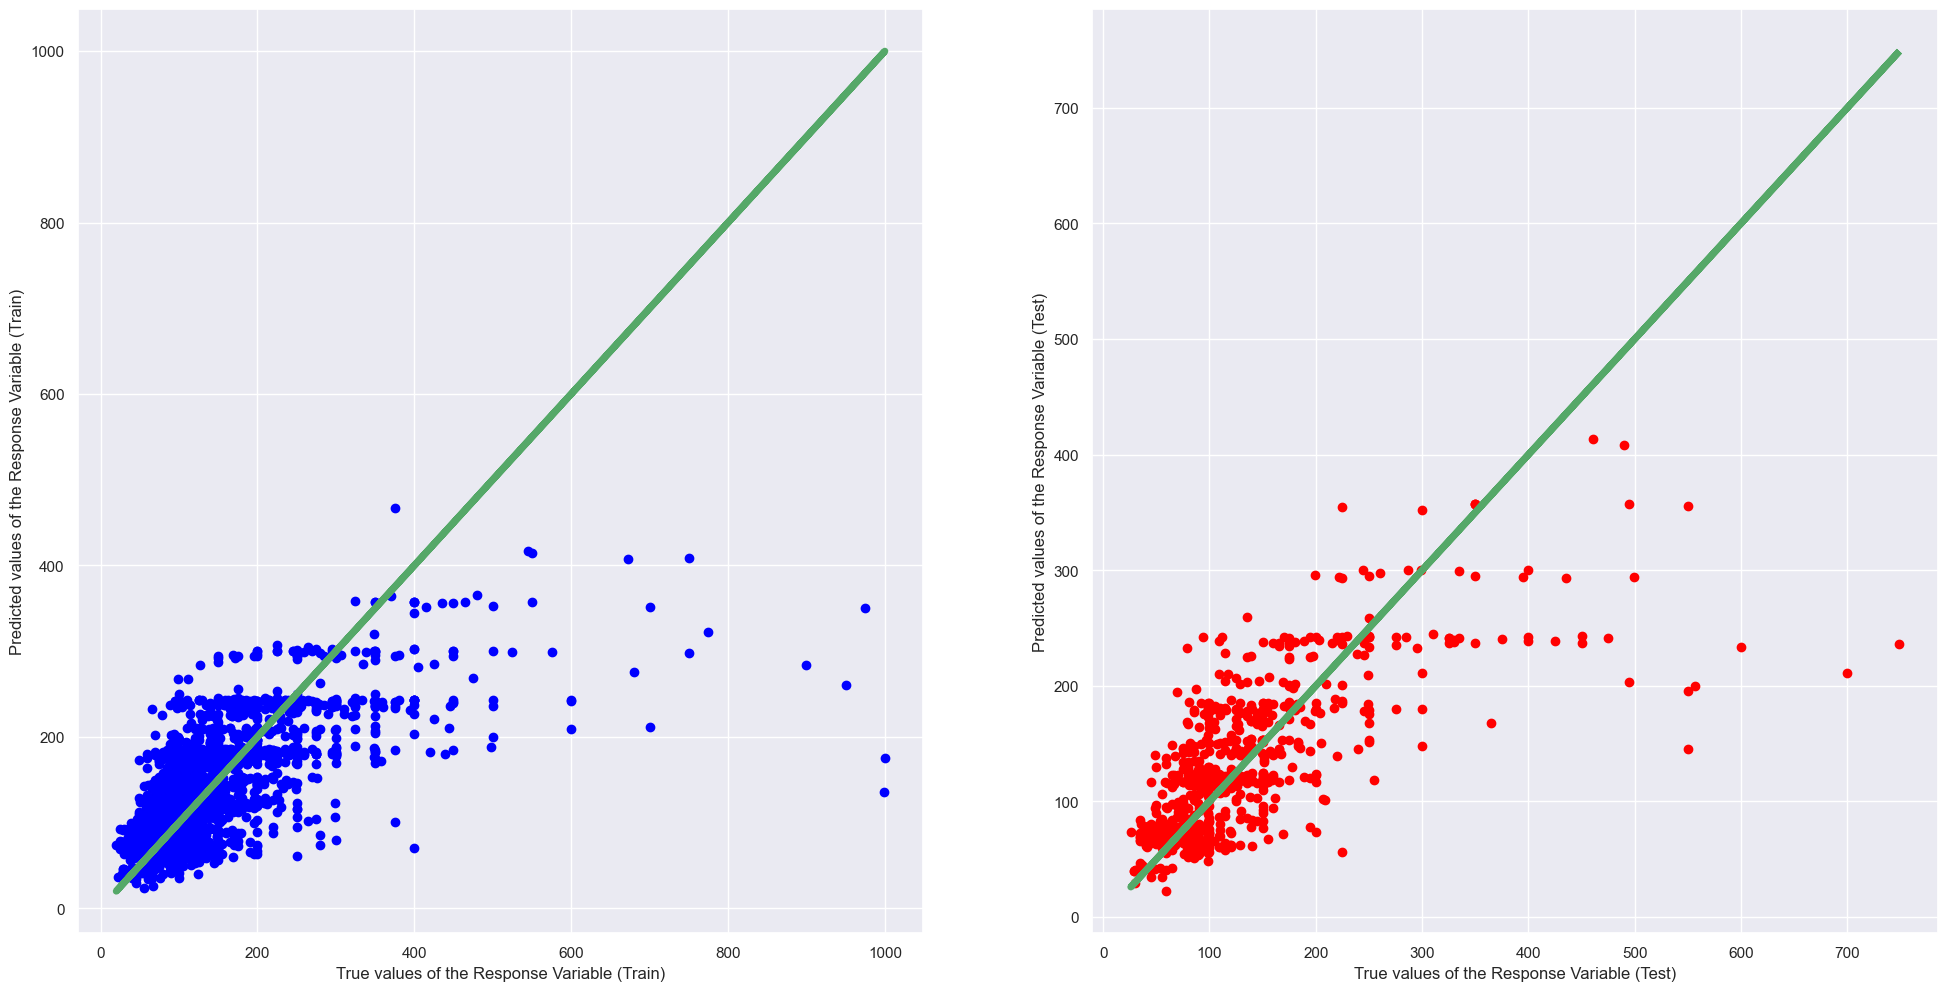

In [20]:
#plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, trainPredictionLR, color = "blue")
axes[0].plot(y_train, y_train, 'g-', linewidth = 5)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, testPredictionLR, color = "red")
axes[1].plot(y_test, y_test, 'g-', linewidth = 5)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")

**Note that**: Points that lie on or near the diagonal line means that the values predicted by the Linear Regression model are highly accurate. If the points are away from the diagonal line, the points have been wrongly predicted. 

### Model 2: Ridge Regression


Ridge Regression is meant to be an upgrade to linear regression. It is similar to linear regression where it can be used to for regression and classification.

Ridge Regression is good at handling overfitting.

The difference in the equation for Ridge Regression is that it penalize RSS by adding another term and search for the minimization.

We can iterate different $\lambda$ values as the additional term to find the best fit for a Ridge Regression model.

Ridge Regression does not drop any predictors unlike Lasso Regression, which is we will observe later on that the beta estimate will only converge to zero, but never reach zero.



In [21]:
#numpy array used for plotting Ridge and Lasson Regression later on
varArr = np.array(["bedrooms", "breakfast", "tv", "white_goods", "elevator", "gym", "hot_tub_sauna_or_pool",
"internet", "pets_allowed", "secure", "accessible","number_of_reviews","room_type_Entire_home_apt",
                              "room_type_Private room", "room_type_Shared_room", "property_type_Apartment",
                              "property_type_Bed_and_Breakfast", "property_type_Condominium", "property_type_House",
                              "property_type_Loft", "property_type_Other", "property_type_Townhouse"])

In [22]:
#initializing the model
ridgeReg = Ridge(alpha=0).fit(X_train,y_train) #alpha is the lambda value

#store the predictions for each lambda/alpha value
ridgeTrainPred = []
ridgeTestPred = []
ridgeR2score = [] # store all the R2 values
lambdaVal = [] #store all values of lambda
#for plotting
ridgeDF = pd.DataFrame({'variable': varArr, 'estimate': ridgeReg.coef_.ravel()})


lambdas = np.arange(0,2000,1) #lambda value of 0 to positive 2000, in intervals of 1

for alpha in lambdas:
    ridgeReg = Ridge(alpha=alpha)
    ridgeReg.fit(X_train, y_train)
    var_name = 'estimate' + str(alpha)
    ridgeDF[var_name] = ridgeReg.coef_.ravel()
    #prediction
    ridgeTrainPred.append(ridgeReg.predict(X_train))
    ridgeTestPred.append(ridgeReg.predict(X_test))
    #storing the R2 scores and lambda value
    ridgeR2score.append(ridgeReg.score(X_train,y_train))
    lambdaVal.append(alpha)

ridgeDF = ridgeDF.set_index('variable').T.rename_axis('estimate').rename_axis(1).reset_index()


bestRidgeR2 = max(ridgeR2score)
print("The highest R2 value: ",bestRidgeR2)
print("The value of lambda that minimises: ",lambdaVal[ridgeR2score.index(bestRidgeR2)])


#Using the best fit Ridge Regression Model's predictions
trainPredictionRidge = ridgeTrainPred[ridgeR2score.index(bestRidgeR2)]
testPredictionRidge = ridgeTestPred[ridgeR2score.index(bestRidgeR2)]
ridgeDF.head()

The highest R2 value:  0.4992785466221811
The value of lambda that minimises:  1


variable,1,bedrooms,breakfast,tv,white_goods,elevator,gym,hot_tub_sauna_or_pool,internet,pets_allowed,...,room_type_Entire_home_apt,room_type_Private room,room_type_Shared_room,property_type_Apartment,property_type_Bed_and_Breakfast,property_type_Condominium,property_type_House,property_type_Loft,property_type_Other,property_type_Townhouse
0,estimate,49.608125,-0.409496,1.174600,0.112949,8.814918,2.689856,3.808741,-2.033703,-2.078973,...,-3.180536e+15,-3.100337e+15,-1.161863e+15,1.690513e+14,3.330715e+13,5.186014e+13,1.692722e+14,3.461739e+13,5.186014e+13,5.884034e+13
1,estimate0,49.608125,-0.409496,1.174600,0.112949,8.814918,2.689856,3.808741,-2.033703,-2.078973,...,-3.180536e+15,-3.100337e+15,-1.161863e+15,1.690513e+14,3.330715e+13,5.186014e+13,1.692722e+14,3.461739e+13,5.186014e+13,5.884034e+13
2,estimate1,50.690510,-0.982369,1.778217,-0.295172,9.281964,2.418319,3.319058,-1.934857,-2.525169,...,1.324740e+01,-1.012136e+01,-9.255997e+00,-2.600705e+00,3.167027e+00,-5.752357e-01,9.385622e-02,3.912361e+00,3.504570e+00,5.256463e-01
3,estimate2,50.669448,-0.983123,1.781523,-0.292981,9.274175,2.421332,3.319399,-1.934733,-2.524456,...,1.324814e+01,-1.012305e+01,-9.253502e+00,-2.602529e+00,3.165968e+00,-5.746523e-01,9.675823e-02,3.910148e+00,3.502222e+00,5.259944e-01
4,estimate3,50.648409,-0.983876,1.784824,-0.290794,9.266400,2.424335,3.319739,-1.934609,-2.523743,...,1.324887e+01,-1.012474e+01,-9.251010e+00,-2.604348e+00,3.164908e+00,-5.740696e-01,9.965560e-02,3.907938e+00,3.499875e+00,5.263415e-01


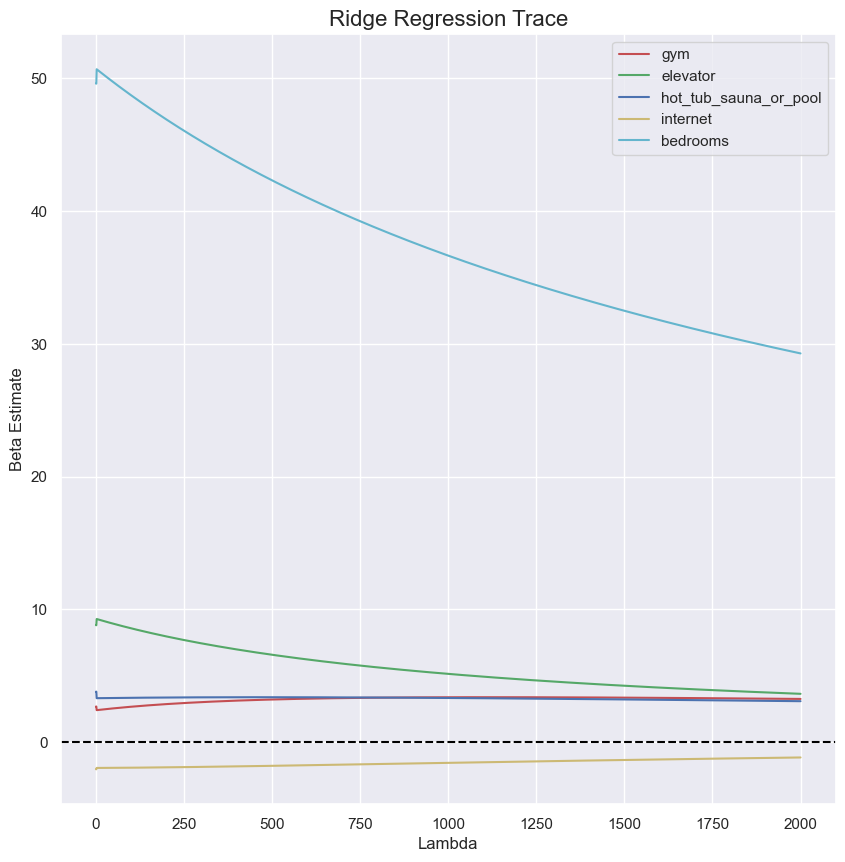

In [23]:
#plotting the Ridge Regression Trace
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(ridgeDF.gym,'r',ridgeDF.elevator,'g',ridgeDF.hot_tub_sauna_or_pool,'b',ridgeDF.internet,'y',ridgeDF.bedrooms,'c')
ax.axhline(y=0, color='black', linestyle='--')

ax.set_xlabel("Lambda")
ax.set_ylabel("Beta Estimate")
ax.set_title("Ridge Regression Trace", fontsize=16)
ax.legend(labels=['gym','elevator','hot_tub_sauna_or_pool','internet','bedrooms'])
ax.grid(True)

From this graph, we can see that the most important predictor among the 5 is <code>bedrooms</code>. For Ridge Regression, the beta estimate of each predictor will converge to zero (but will never reach zero) as lambda increases, the faster it converges to zero, the less important the predictor is. For this case, the most important predictor is <code>bedrooms</code>. The reason why the beta estimate does not reach zero is because Ridge Regression does not drop any predictors, unlike Lasso Regression, which we will observe later on.

Text(0, 0.5, 'Predicted values of the Response Variable (Test)')

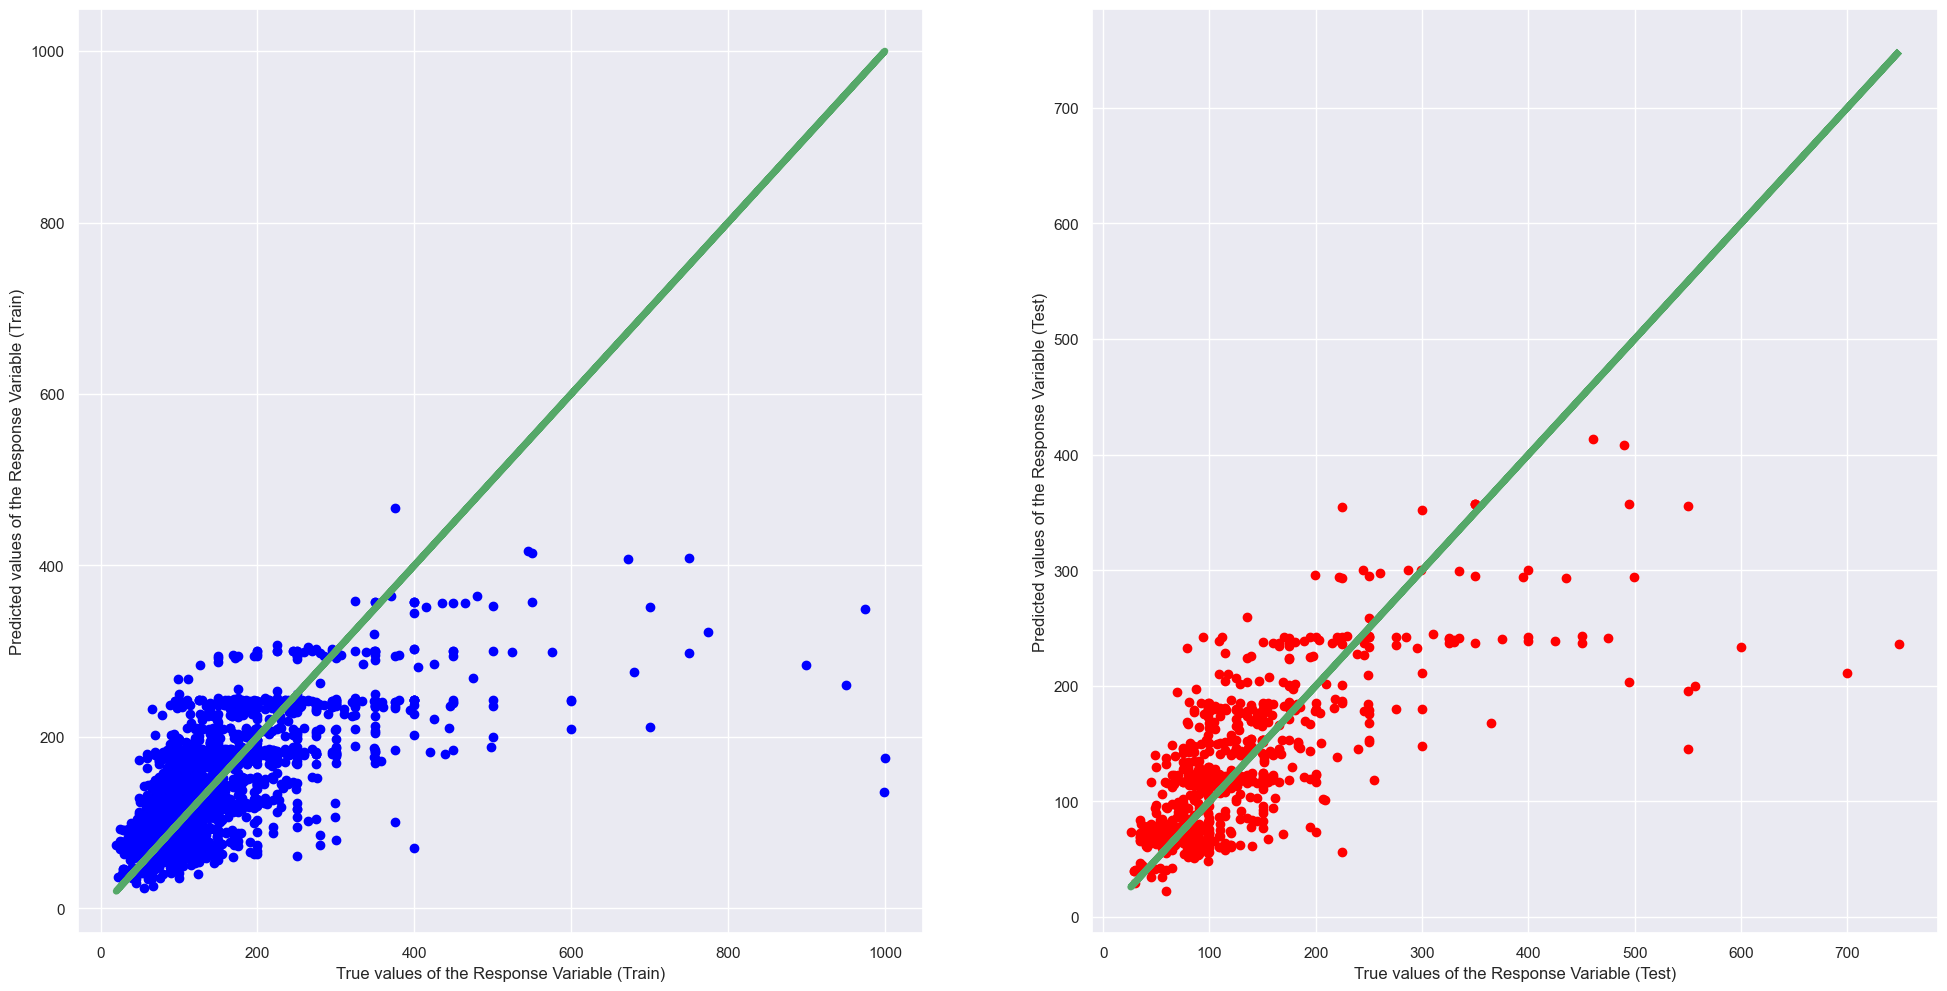

In [24]:
#plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, trainPredictionRidge, color = "blue")
axes[0].plot(y_train, y_train, 'g-', linewidth = 5)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, testPredictionRidge, color = "red")
axes[1].plot(y_test, y_test, 'g-', linewidth = 5)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")

**Note that**: Points that lie on or near the diagonal line means that the values predicted by the Ridge Regression model are highly accurate. If the points are away from the diagonal line, the points have been wrongly predicted. 

### Model 3: Lasso Regression

Lasso Regression is similar to Ridge Regression, meant to be an upgrade to linear regression, it also can be used for Regression and Classification.

Lasso Regression can be used for feature selection, where some predictors will be dropped after a lambda reaches a certain value.

Lasson Regression also requires a $\lambda$ value to be iterated to find the best fit.


In [25]:
#initialising the model
lassoReg = Lasso(alpha=1)
lassoReg.fit(X_train, y_train)
#stores prediction
lassoTrainPred = []
lassoTestPred = []
lassoR2score=[] #stores R2 value
lassoDF = pd.DataFrame({'variable': varArr, 'estimate': lassoReg.coef_.ravel()})

lambdas = np.arange(0.01, 8.01, 0.02)#lambda value of 0.01 to 8.01, in intervals of 0.02

for alpha in lambdas:
    lassoReg = Lasso(alpha=alpha)
    lassoReg.fit(X_train, y_train)
    var_name = 'estimate' + str(alpha)
    lassoDF[var_name] = lassoReg.coef_.ravel()
    #prediction
    lassoTrainPred.append(lassoReg.predict(X_train))
    lassoTestPred.append(lassoReg.predict(X_test))
    #storing the r2 score 
    lassoR2score.append(lassoReg.score(X_train,y_train))


bestLassoR2 = max(lassoR2score)
print("The highest R2 value: ",bestLassoR2)


#Using the best fit Lasso Regression Model's predictions
trainPredictionLasso = lassoTrainPred[lassoR2score.index(bestLassoR2)]
testPredictionLasso = lassoTestPred[lassoR2score.index(bestLassoR2)]

lassoDF = lassoDF.set_index('variable').T.rename_axis('estimate').rename_axis(1).reset_index()

lassoDF.head()

The highest R2 value:  0.4992783368698215


variable,1,bedrooms,breakfast,tv,white_goods,elevator,gym,hot_tub_sauna_or_pool,internet,pets_allowed,...,room_type_Entire_home_apt,room_type_Private room,room_type_Shared_room,property_type_Apartment,property_type_Bed_and_Breakfast,property_type_Condominium,property_type_House,property_type_Loft,property_type_Other,property_type_Townhouse
0,estimate,50.297409,-0.000000,0.982417,-0.000000,7.777959,2.207209,2.760095,-0.976255,-1.523063,...,22.927511,-0.0,-4.663839,-0.840974,1.873903,0.000000,0.0,3.142940,2.481794,0.000000
1,estimate0.01,50.708161,-0.971852,1.765728,-0.286602,9.266619,2.411834,3.313577,-1.926259,-2.515969,...,23.619287,-0.0,-5.458671,-2.667716,3.138794,-0.585605,0.0,3.889662,3.470769,0.485580
2,estimate0.03,50.701180,-0.952279,1.747326,-0.265104,9.220416,2.404892,3.303321,-1.908825,-2.496140,...,23.601841,-0.0,-5.443765,-2.623880,3.115987,-0.549494,0.0,3.877010,3.454154,0.469377
3,estimate0.049999999999999996,50.693800,-0.932539,1.728778,-0.243699,9.174538,2.397901,3.293134,-1.891412,-2.476309,...,23.584920,-0.0,-5.428782,-2.580547,3.093133,-0.513539,0.0,3.864271,3.437406,0.453178
4,estimate0.06999999999999999,50.687141,-0.913100,1.710495,-0.222126,9.128079,2.390996,3.282821,-1.873962,-2.456483,...,23.567051,-0.0,-5.413938,-2.536308,3.070364,-0.477302,0.0,3.851687,3.420897,0.436971


/var/folders/9p/gm2n68xn7n1bhds792y57yg40000gn/T/ipykernel_59594/2144987329.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(-1, 100, 1))


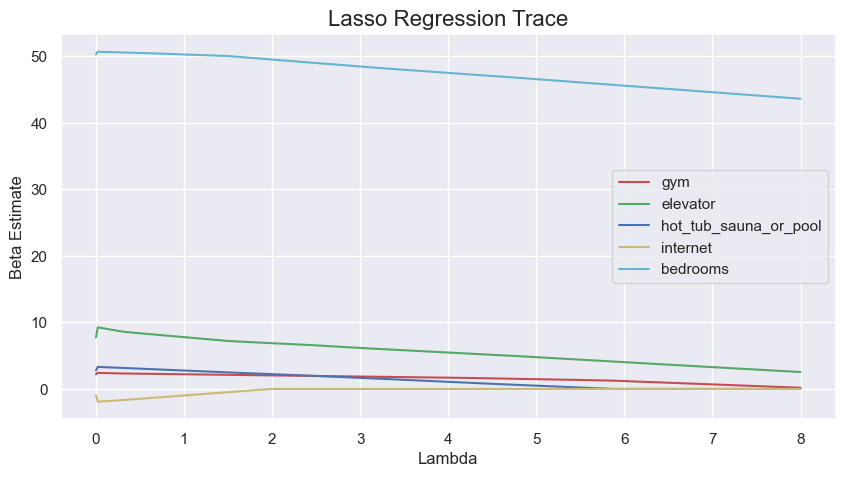

In [26]:
#Plot the Lasso Regression Trace
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lassoDF.gym,'r',lassoDF.elevator,'g',lassoDF.hot_tub_sauna_or_pool,'b',lassoDF.internet,'y',lassoDF.bedrooms,'c')
ax.set_xlabel("Lambda")
ax.set_xticklabels(np.arange(-1, 100, 1))
ax.set_ylabel("Beta Estimate")
ax.set_title("Lasso Regression Trace", fontsize=16)
ax.legend(labels=['gym','elevator','hot_tub_sauna_or_pool','internet','bedrooms'])
ax.grid(True)


From this graph, we can see that the most important predictor among the 5 is also <code>bedrooms</code>. For Lasso Regression, the faster the beta estimate of the predictor reaches zero (the predictor has been dropped) as lambda increases, the less important the predictor is. As we can see from the graph, <code>bedrooms</code> does not even hit zero after when has reached its highest value of 8, compared to the beta estimate of <code>hot_tub_sauna_or_pool</code> which reached zero a lot faster than <code>bedrooms</code>.

Text(0, 0.5, 'Predicted values of the Response Variable (Test)')

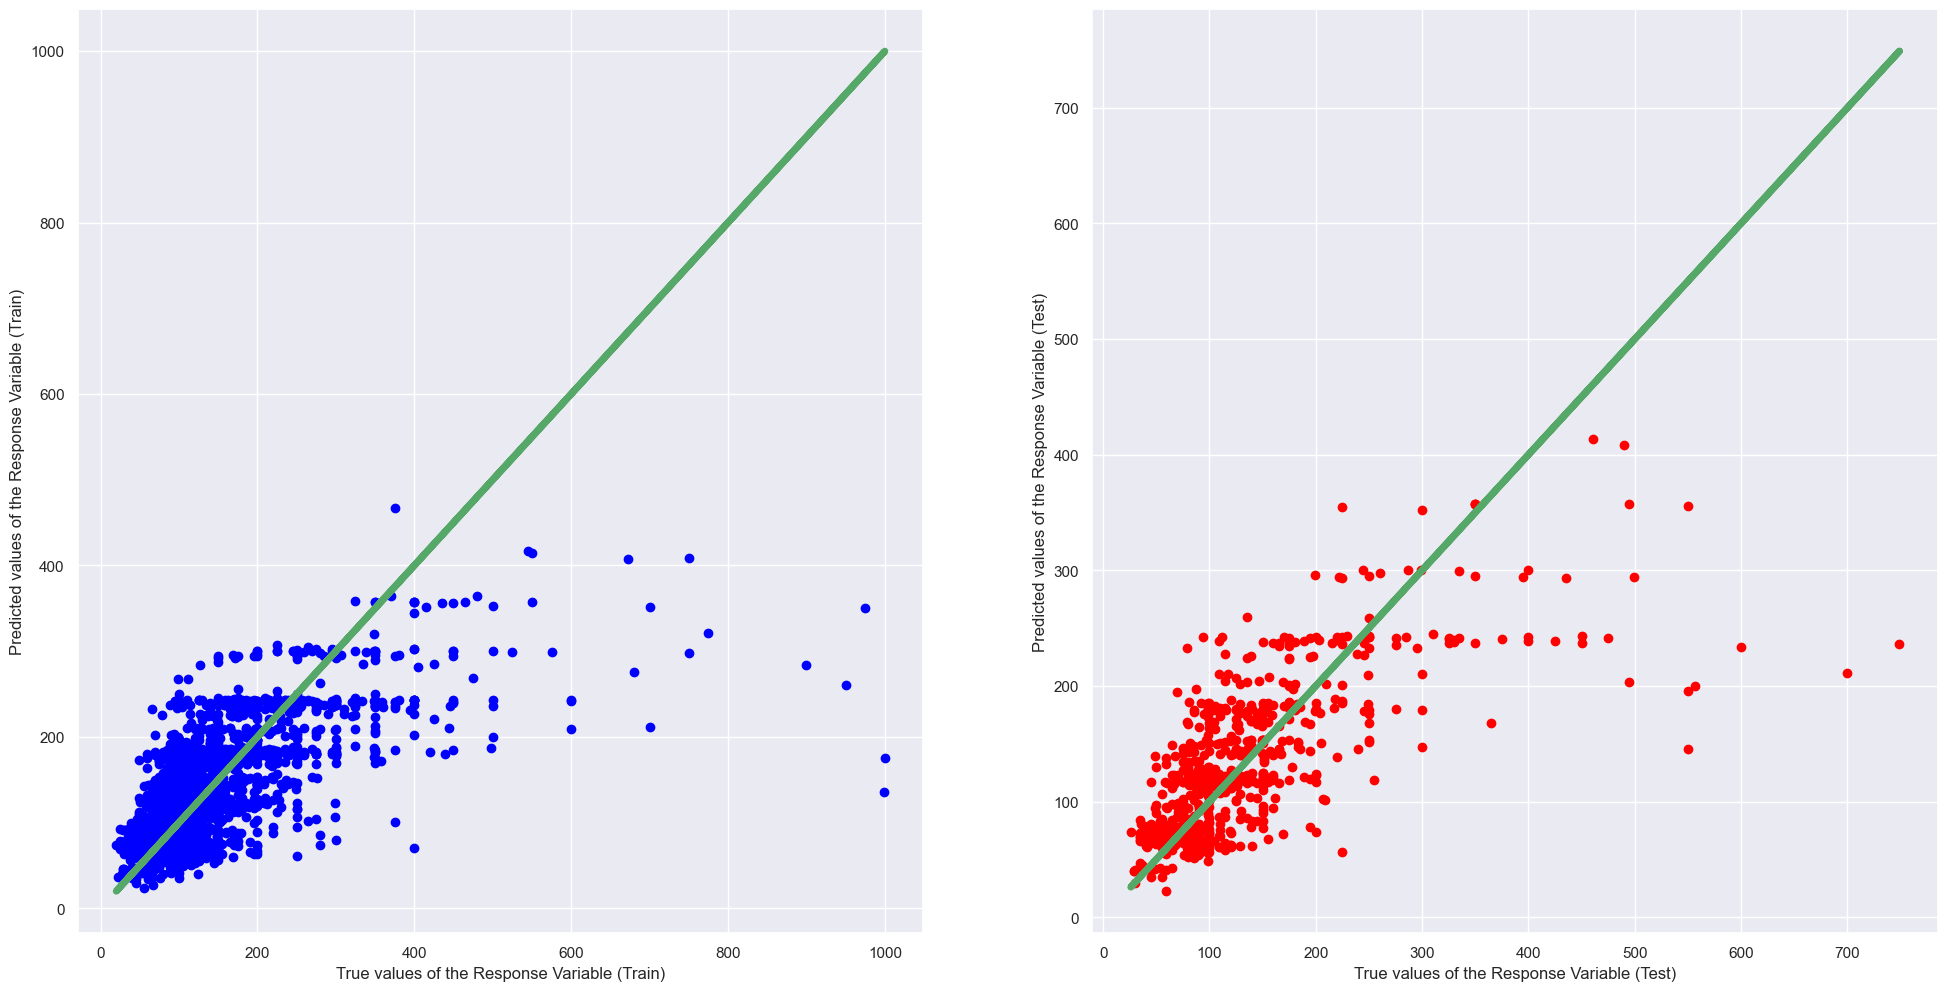

In [27]:
#plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, trainPredictionLasso, color = "blue")
axes[0].plot(y_train, y_train, 'g-', linewidth = 5)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, testPredictionLasso, color = "red")
axes[1].plot(y_test, y_test, 'g-', linewidth = 5)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")

**Note that**: Points that lie on or near the diagonal line means that the values predicted by the Lasso Regression model are highly accurate. If the points are away from the diagonal line, the points have been wrongly predicted. 

### Model 4: Random Forest Regression

Random Forest is an emsemble technique that is able to perform both Regression and Classification tasks with the use of multiple decision trees and a technique that is called Bootstrap Aggression. The idea behind this technique is to combine multiple decision trees in its prediction rather than replying on individual decision trees. 

Here, we use the RandomForestRegressor to help predict the price.

In [28]:
# Tuning of Parameters

# random_grid = {'n_estimators': [2000],
#                'max_features': [2,5],
#                'max_depth': [40,70],
#                'min_samples_split': [40,50],
#                'max_leaf_nodes':[50,70],
#                'max_features': [2,5]}
# rf_tune = RandomForestRegressor()
# rf_random = GridSearchCV(estimator = rf_tune, param_grid = random_grid, cv = 3, verbose=2,n_jobs = 2)

# rf_random.fit(X_train,y_train)

# print(rf_random.best_estimator_)

To optimize the parameters used in the Random Forest Regression modelling algorithm, we first tune the parameters - in which GridSearchCV was used to optimize the parameters to determine the values that impact the model in order to enable the algorithm to perform at its best. In this case, while we managed to get the optimal parameter values (for at least the more significant parameters), we commented off the code as it would take a decent amount of time to process. The output of the code is as follows:

RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=10,
                      max_features=5, max_leaf_nodes=30,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=5,
                      min_weight_fraction_leaf=0.0, n_estimators=2000,
                      n_jobs=None, oob_score=False, random_state=None,
                      verbose=0, warm_start=False)

In [29]:
#creating and fitting the model
RF = RandomForestRegressor(n_estimators=2000, max_depth=40,min_samples_split = 50,
                           max_leaf_nodes = 70,max_features = 5).fit(X_train,y_train)

# predicting the training and testing sets
trainPredictin_RF = RF.predict(X_train)
testPredictin_RF =RF.predict(X_test)

/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [30]:
importancesRF = RF.feature_importances_
feat_imp1 = pd.DataFrame(importancesRF, columns=['Weight'], index=X_train.columns)
feat_imp1.sort_values('Weight', inplace=True)
feat_imp1

,Weight
property_type_Bed_and_Breakfast,0.001733
property_type_Condominium,0.002123
property_type_Townhouse,0.003023
accessible,0.003293
property_type_Loft,0.003448
secure,0.004559
breakfast,0.004684
internet,0.004992
pets_allowed,0.005221
white_goods,0.007242


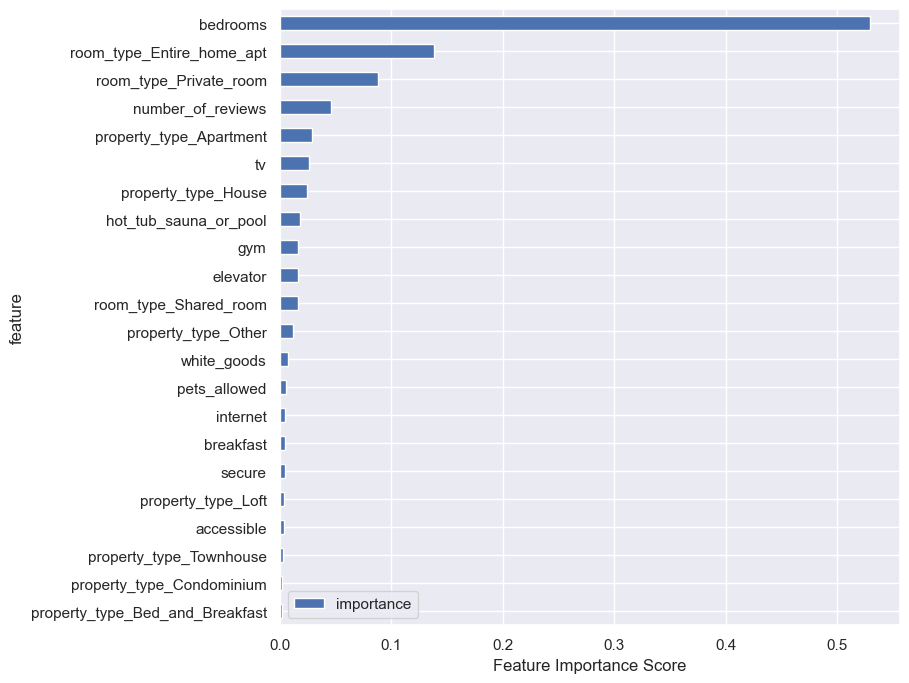

In [31]:
feat_imp = pd.DataFrame({'importance':RF.feature_importances_})  
feat_imp['feature'] = X_train.columns
feat_imp.sort_values(by='importance', ascending=False, inplace=True)

feat_imp.sort_values(by='importance', inplace=True)
feat_imp = feat_imp.set_index('feature', drop=True)
feat_imp.plot.barh(figsize=(8,8))
plt.xlabel('Feature Importance Score')
plt.show()

Importance provides a score that indicates how useful or valuable each feature was in the construction of the decision trees within the model. The more a variable is used to make key decisions with decision trees, the higher its relative importance.

As such, feature importance can be used to interpret our data to understand the most important features that define our predictions. In this case, looking at the bar chart above, the predictor variable that is associated with a taller bar means that the variable has a higher importance in the Random Tree Regression Model in predicting price. 

Text(0, 0.5, 'Predicted values of the Response Variable (Test)')

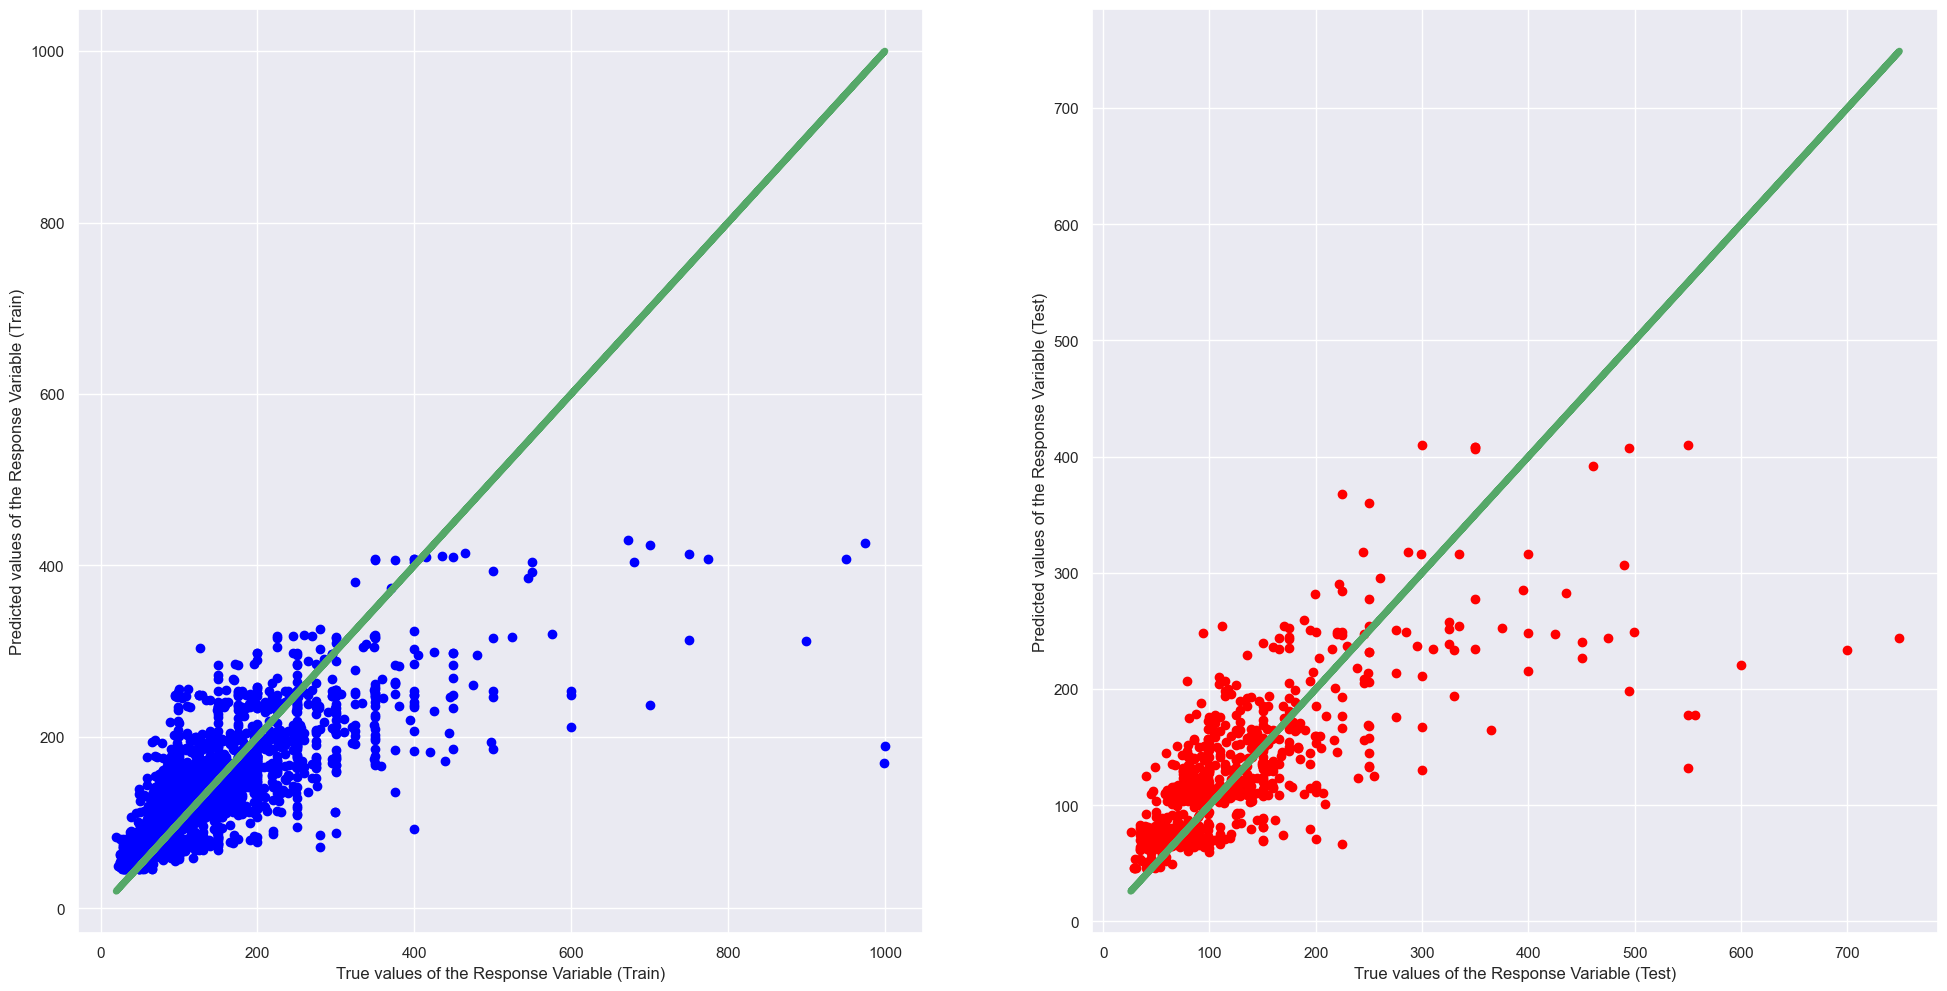

In [32]:
#plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, trainPredictin_RF, color = "blue")
axes[0].plot(y_train, y_train, 'g-', linewidth = 5)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, testPredictin_RF, color = "red")
axes[1].plot(y_test, y_test, 'g-', linewidth = 5)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")

**Note that**: Points that lie on or near the diagonal line means that the values predicted by the Random Forest Regression model are highly accurate. If the points are away from the diagonal line, the points have been wrongly predicted. 

### Model 5 : XGBoost

XGBoost is an open source library that provides a high-performance implementation of gradient boost decision trees (similar to the decision trees that we have learnt). It is a machine learning model that is able to perform prediction tasks regardless of Regression or Classification. 

The key idea of Gradient Boosted Decision Trees is that they build a series of trees in which each tree is trained so that it attempts to correct the mistakes of the previous tree in the seroes.

In [33]:
#Tuning the Parameters

# parameters_for_testing = {
#     'colsample_bytree':[0.3,0.5],
#     'learning_rate':[0.1,0.5],
#     'alpha': [10,12],
#     'max_depth':[3,5],
#     'n_estimators':[2000],  
# }

                    
# xgb_model = xgb.XGBRegressor(learning_rate =0.1, n_estimators=1000, max_depth=5,
#      gamma=0, colsample_bytree=0.8)

# gsearch1 = GridSearchCV(estimator = xgb_model, param_grid = parameters_for_testing, n_jobs=6,iid=False, verbose=10,scoring='neg_mean_squared_error')
# gsearch1.fit(X_train,y_train)

# print(gsearch1.best_estimator_)

To optimize the parameters used in the XGBoost modelling algorithm, we first tune the parameters - in which GridSearchCV was used to optimize the parameters to determine the values that impact the model in order to enable the algorithm to perform at its best. In this case, while we managed to get the optimal parameter values (for at least the more significant parameters), we commented off the code as it would take a decent amount of time to process. The output of the code is as follows:

XGBRegressor(alpha=10, base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=0.3, gamma=0,
             importance_type='gain', learning_rate=0.1, max_delta_step=0,
             max_depth=3, min_child_weight=1, missing=None, n_estimators=2000,
             n_jobs=1, nthread=None, objective='reg:linear', random_state=0,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
             silent=None, subsample=1, verbosity=1)

In [34]:
#fitting and Training the model for Train & Test sets
xgb_reg = xgb.XGBRegressor(objective ='reg:linear', colsample_bytree = 0.3, learning_rate = 0.1,
                max_depth = 3, alpha = 10, n_estimators = 2000)

xgb_reg.fit(X_train,y_train)

#predicting using the model
trainPredictin_xgb_reg = xgb_reg.predict(X_train)
testPredictin_xgb_reg = xgb_reg.predict(X_test)

/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [09:12:18] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


In [35]:
import shutil

# Graphviz's `dot` program must be installed and on PATH to render the tree below
# (macOS: `brew install graphviz`, Ubuntu: `apt install graphviz`, Windows: https://graphviz.org/download/)
print("dot found at:", shutil.which("dot"))

dot found at: /opt/homebrew/bin/dot


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


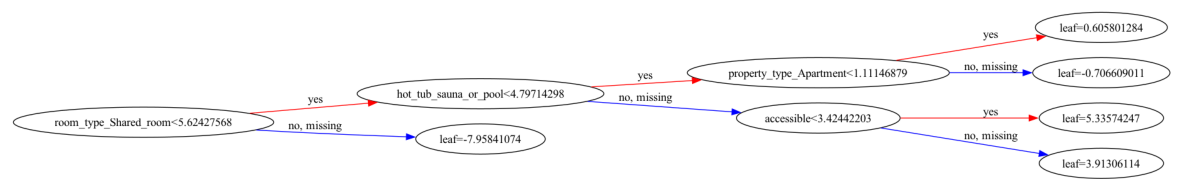

In [36]:
#ploting decision tree 
xgb.plot_tree(xgb_reg, num_trees=0, rankdir='LR')
fig = plt.gcf()
fig.set_size_inches(15, 20)

In [37]:
# Weightage/Importance of each variable 
ft_weights_xgb_reg = pd.DataFrame(xgb_reg.feature_importances_, columns=['weight'], index=X_train.columns)
ft_weights_xgb_reg.sort_values('weight', inplace=True)
ft_weights_xgb_reg

,weight
property_type_Townhouse,0.004898
internet,0.007655
property_type_Loft,0.007772
accessible,0.008137
breakfast,0.008310
property_type_Condominium,0.008588
property_type_Bed_and_Breakfast,0.009498
white_goods,0.009867
secure,0.010333
pets_allowed,0.019445


Importance provides a score that indicates how useful or valuable each feature was in the construction of the boosted decision trees within the model. The more a variable is used to make key decisions with decision trees, the higher its relative importance.

As such, feature importance can be used to interpret our data to understand the most important features that define our predictions. In this case, looking at the table above, the predictor variable that is associated with a higher number means that the variable has a higher importance in the XGBoost Regression Model in predicting price. 

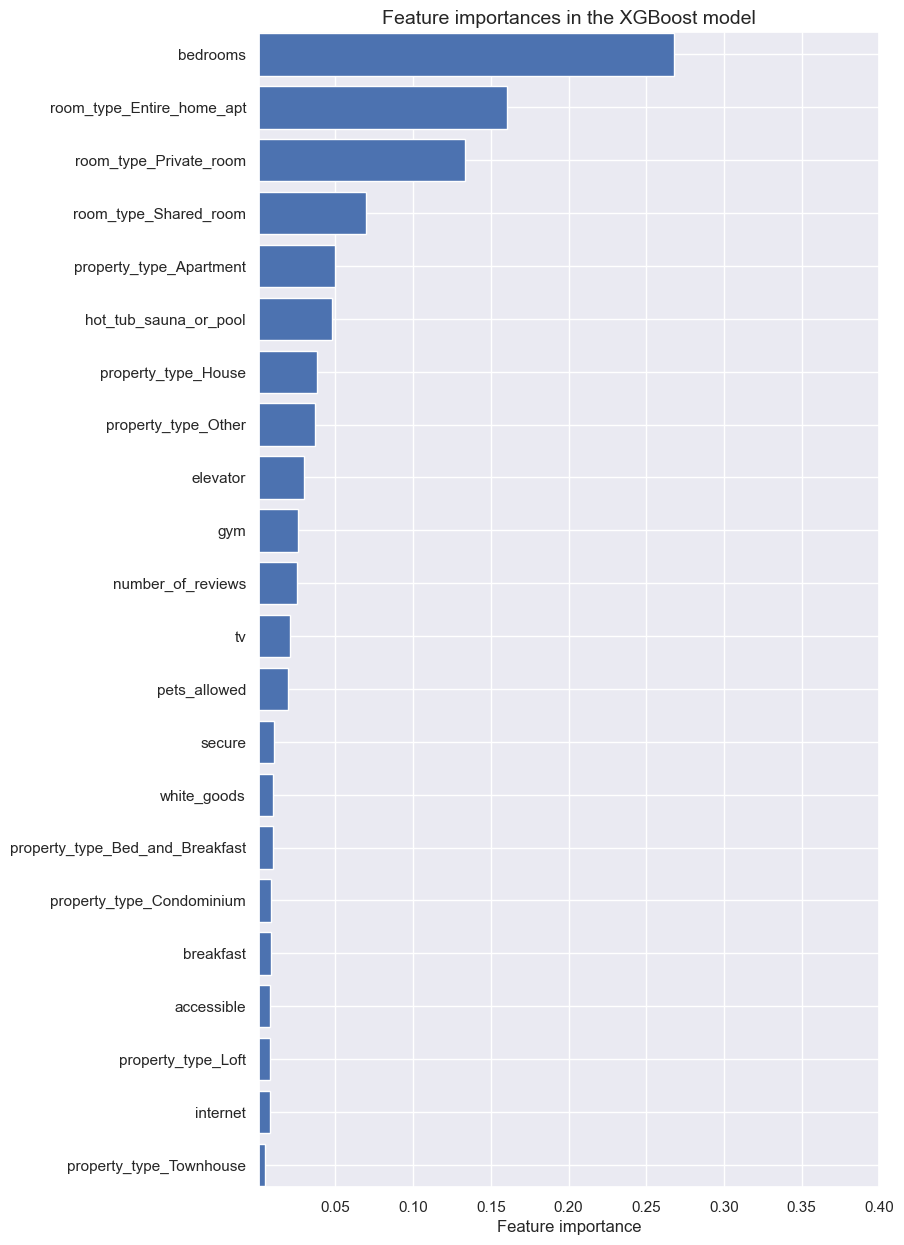

In [38]:
#plotting feature importances
plt.figure(figsize=(8,15))
plt.barh(ft_weights_xgb_reg.index, ft_weights_xgb_reg.weight, align='center') 
plt.title("Feature importances in the XGBoost model", fontsize=14)
plt.xlabel("Feature importance")
plt.margins(y=0.001)
plt.xlim(0.001, 0.4)
plt.show()

Text(0, 0.5, 'Predicted values of the Response Variable (Test)')

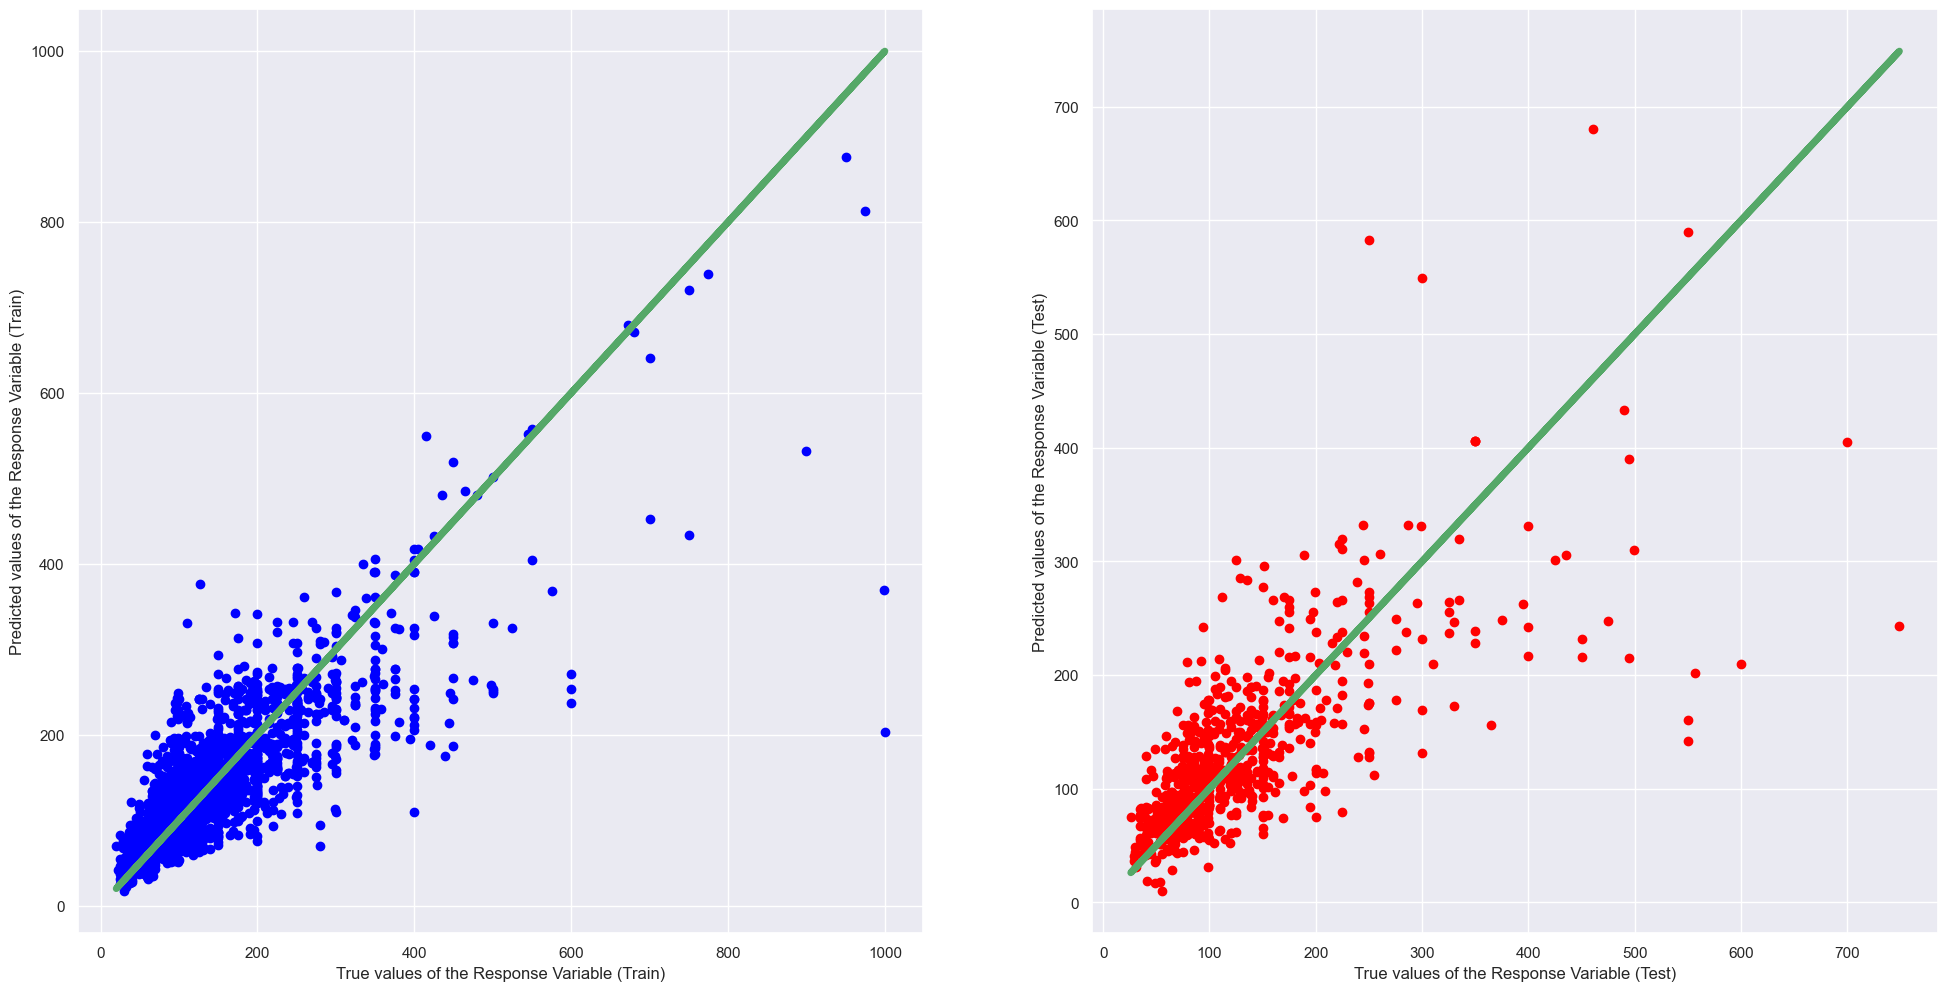

In [39]:
#plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, trainPredictin_xgb_reg, color = "blue")
axes[0].plot(y_train, y_train, 'g-', linewidth = 5)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, testPredictin_xgb_reg, color = "red")
axes[1].plot(y_test, y_test, 'g-', linewidth = 5)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")

**Note that**: Points that lie on or near the diagonal line means that the values predicted by the XGBoost Regression model are highly accurate. If the points are away from the diagonal line, the points have been wrongly predicted.

### Model 6: CatBoost 

CatBoost is a high performance open source gradient boosting on decision trees. It can be used to solve both Classification and Regression problems. 

In [40]:
# catBoost = CatBoostRegressor()
# parameters = {'depth'         : [3,5],
#                 'learning_rate' : [0.1,0.5],
#                 'iterations'    : [2000]
#                 }
# grid = GridSearchCV(estimator=catBoost, param_grid = parameters, cv = 2, n_jobs=6)
# grid.fit(X_train, y_train)

# print("\n The best parameters across ALL searched params:\n",
#           grid.best_params_)

To optimize the parameters used in the CatBoost modelling algorithm, we first tune the parameters - in which GridSearchCV was used to optimize the parameters to determine the values that impact the model in order to enable the algorithm to perform at its best. In this case, while we managed to get the optimal parameter values (for at least the more significant parameters), we commented off the code as it would take a decent amount of time to process. The output of the code is as follows:

{'depth': 3, 'iterations': 2000, 'learning_rate': 0.1}

In [41]:
#Creating and fitting the model
CatB=CatBoostRegressor(iterations=2000, depth=3, learning_rate=0.1,loss_function='RMSE')
CatB.fit(X_train, y_train,plot=True);

#Predicting based on the model
trainPrediction_CatB = CatB.predict(X_train)
testPrediction_CatB = CatB.predict(X_test)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 86.4152966	total: 58.9ms	remaining: 1m 57s
1:	learn: 83.2210678	total: 59.2ms	remaining: 59.2s
2:	learn: 80.3421271	total: 59.5ms	remaining: 39.6s
3:	learn: 77.9177077	total: 59.7ms	remaining: 29.8s
4:	learn: 75.8215661	total: 60.6ms	remaining: 24.2s
5:	learn: 74.0105631	total: 61.5ms	remaining: 20.4s
6:	learn: 72.4206550	total: 61.8ms	remaining: 17.6s
7:	learn: 71.2478681	total: 62.1ms	remaining: 15.5s
8:	learn: 70.0814758	total: 62.3ms	remaining: 13.8s
9:	learn: 69.0357095	total: 62.6ms	remaining: 12.5s
10:	learn: 68.2240479	total: 62.8ms	remaining: 11.4s
11:	learn: 67.5137015	total: 63.1ms	remaining: 10.4s
12:	learn: 66.8491200	total: 63.3ms	remaining: 9.67s
13:	learn: 66.3935390	total: 63.5ms	remaining: 9.01s
14:	learn: 65.8732355	total: 63.8ms	remaining: 8.44s
15:	learn: 65.4198170	total: 64ms	remaining: 7.94s
16:	learn: 65.0044821	total: 64.3ms	remaining: 7.51s
17:	learn: 64.7507991	total: 64.6ms	remaining: 7.11s
18:	learn: 64.4222283	total: 64.9ms	remaining: 6.76s
19:	

849:	learn: 52.4761133	total: 246ms	remaining: 333ms
850:	learn: 52.4757797	total: 246ms	remaining: 333ms
851:	learn: 52.4742773	total: 247ms	remaining: 332ms
852:	learn: 52.4734743	total: 247ms	remaining: 332ms
853:	learn: 52.4707834	total: 247ms	remaining: 331ms
854:	learn: 52.4652871	total: 247ms	remaining: 331ms
855:	learn: 52.4608966	total: 247ms	remaining: 331ms
856:	learn: 52.4578324	total: 248ms	remaining: 330ms
857:	learn: 52.4566581	total: 248ms	remaining: 330ms
858:	learn: 52.4506532	total: 248ms	remaining: 329ms
859:	learn: 52.4396441	total: 248ms	remaining: 329ms
860:	learn: 52.4238318	total: 248ms	remaining: 329ms
861:	learn: 52.4209082	total: 249ms	remaining: 328ms
862:	learn: 52.4171262	total: 249ms	remaining: 328ms
863:	learn: 52.4159911	total: 249ms	remaining: 327ms
864:	learn: 52.4102366	total: 249ms	remaining: 327ms
865:	learn: 52.4091644	total: 249ms	remaining: 327ms
866:	learn: 52.3942869	total: 250ms	remaining: 326ms
867:	learn: 52.3875090	total: 250ms	remaining:

1741:	learn: 50.5964896	total: 434ms	remaining: 64.2ms
1742:	learn: 50.5935423	total: 434ms	remaining: 64ms
1743:	learn: 50.5926223	total: 434ms	remaining: 63.7ms
1744:	learn: 50.5925788	total: 434ms	remaining: 63.5ms
1745:	learn: 50.5924719	total: 435ms	remaining: 63.2ms
1746:	learn: 50.5904349	total: 435ms	remaining: 63ms
1747:	learn: 50.5897368	total: 435ms	remaining: 62.7ms
1748:	learn: 50.5871882	total: 435ms	remaining: 62.5ms
1749:	learn: 50.5800167	total: 436ms	remaining: 62.2ms
1750:	learn: 50.5799669	total: 436ms	remaining: 62ms
1751:	learn: 50.5792265	total: 436ms	remaining: 61.7ms
1752:	learn: 50.5788277	total: 436ms	remaining: 61.4ms
1753:	learn: 50.5787494	total: 436ms	remaining: 61.2ms
1754:	learn: 50.5787463	total: 436ms	remaining: 60.9ms
1755:	learn: 50.5781785	total: 437ms	remaining: 60.7ms
1756:	learn: 50.5761674	total: 437ms	remaining: 60.4ms
1757:	learn: 50.5753274	total: 437ms	remaining: 60.2ms
1758:	learn: 50.5750376	total: 437ms	remaining: 59.9ms
1759:	learn: 50.

(0.001, 20.0)

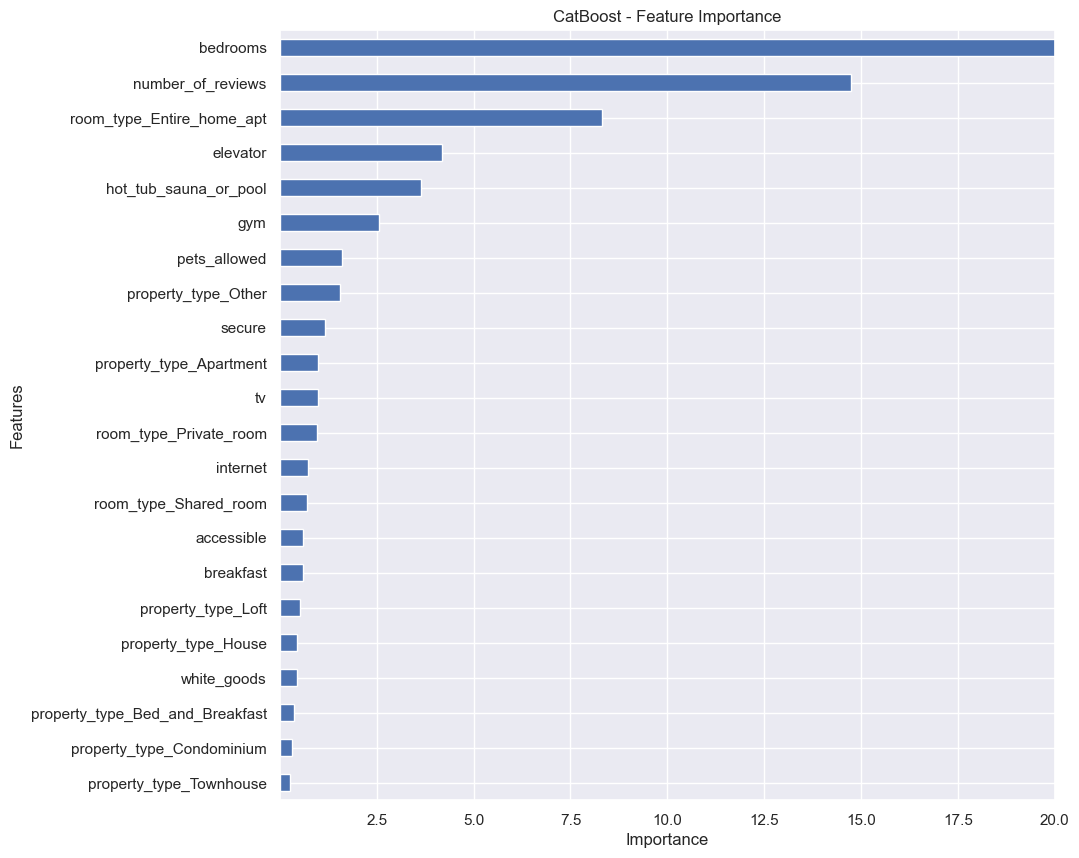

In [42]:
#plotting the feature importance diagram
feature_impCatB = pd.DataFrame({'imp': CatB.feature_importances_, 'col': X.columns})
feature_impCatB = feature_impCatB.sort_values(['imp', 'col'], ascending=[True, False]).iloc[-30:]
feature_impCatB.plot(kind='barh', x='col', y='imp', figsize=(10, 10), legend=None)
plt.title('CatBoost - Feature Importance')
plt.ylabel('Features')
plt.xlabel('Importance');
plt.xlim(0.001, 20.0)

Importance provides a score that indicates how useful or valuable each feature was in the construction of the boosted decision trees within the model. The more a variable is used to make key decisions with decision trees, the higher its relative importance.

As such, feature importance can be used to interpret our data to understand the most important features that define our predictions. In this case, looking at the bar chart above, the predictor variable that is associated with a longer bar means that the variable has a higher importance in the CatBoost Regression Model in predicting price. 

Text(0, 0.5, 'Predicted values of the Response Variable (Test)')

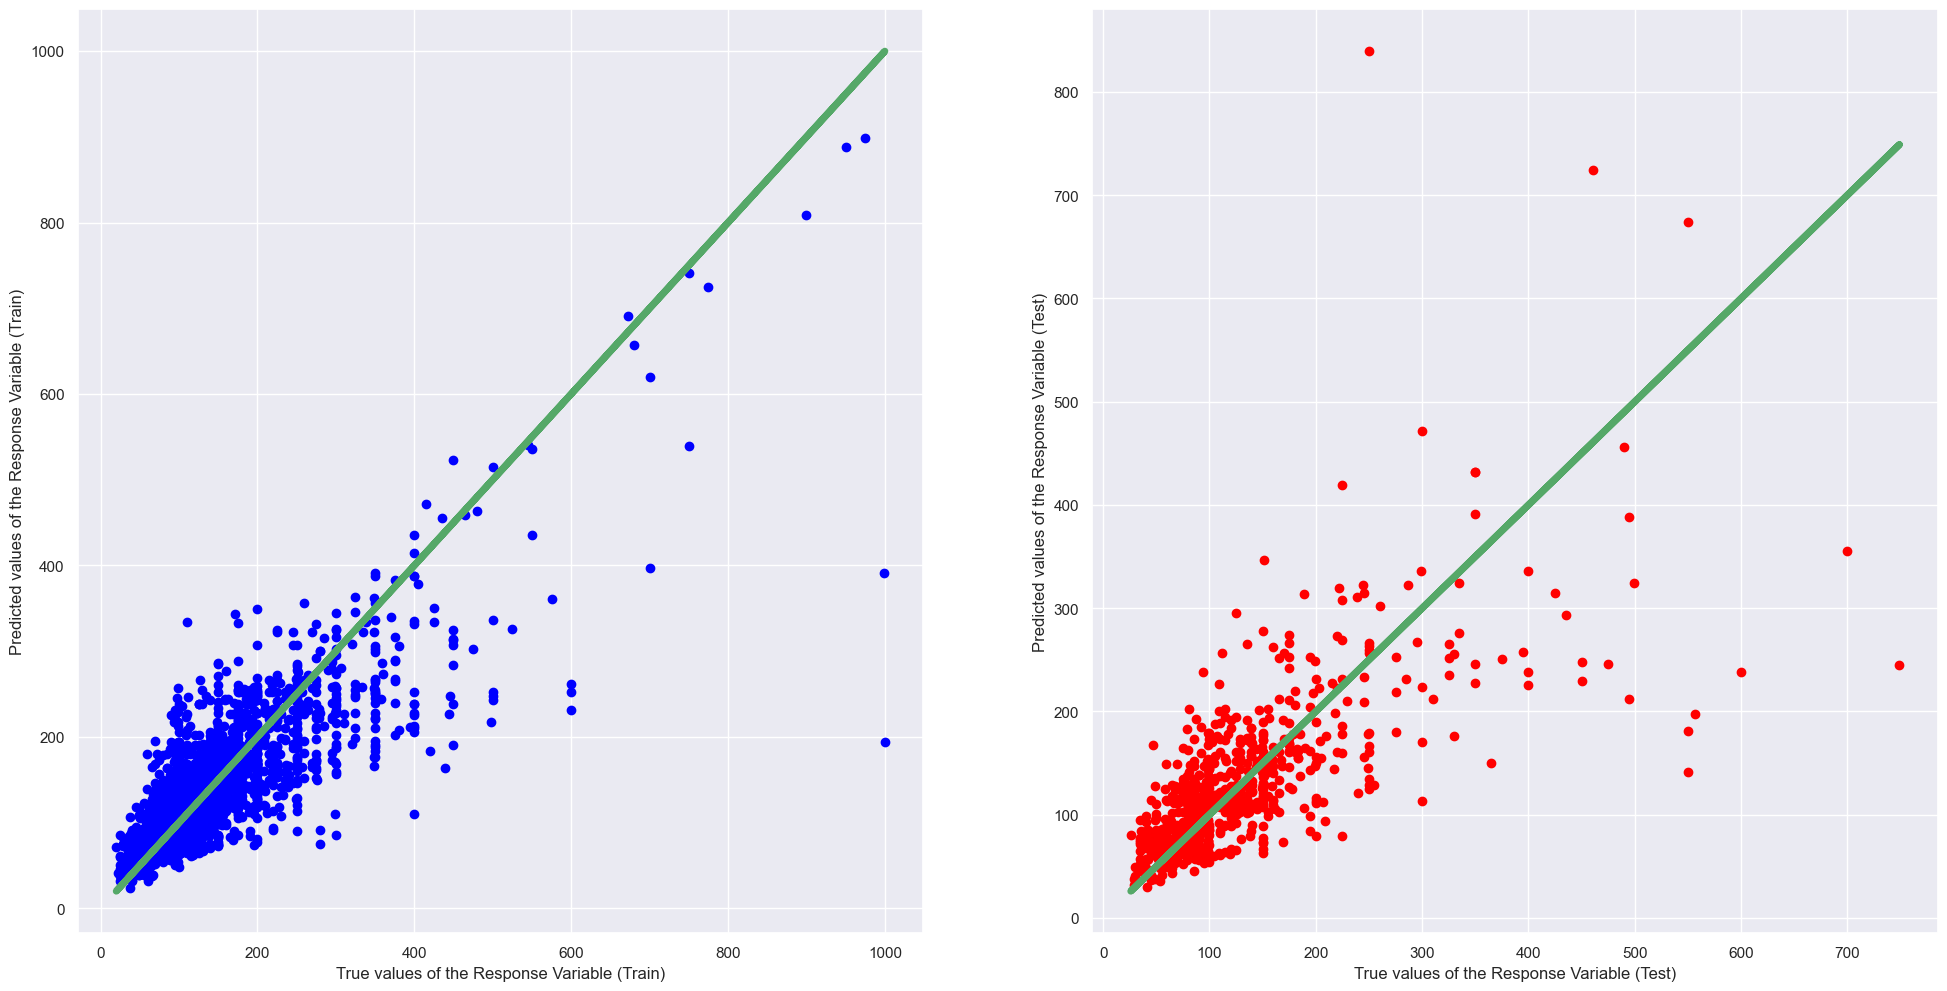

In [43]:
#plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, trainPrediction_CatB, color = "blue")
axes[0].plot(y_train, y_train, 'g-', linewidth = 5)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, testPrediction_CatB, color = "red")
axes[1].plot(y_test, y_test, 'g-', linewidth = 5)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")

**Note that**: Points that lie on or near the diagonal line means that the values predicted by the CatBoost Regression model are highly accurate. If the points are away from the diagonal line, the points have been wrongly predicted.

### Evaluation of Models

#### Train Test Split
Validation of model performance is done using Train/Test Set Split in which the data set is split into 80% : 20%. 

In [44]:
# Results of Model
print ("Goodness Fit on the Models (Train/Test Split):")
print()
print("Performance Metrics for Test Set")
print("--------------------------------")
print("Linear Regression (MSE):", round(mean_squared_error(y_test, testPredictionLR),4))
print("Linear Regression (R^2):", round(r2_score(y_test, testPredictionLR),4))

print("\nRidge Regression (MSE):", round(mean_squared_error(y_test, testPredictionRidge),4))
print("Ridge Regression (R^2):", round(r2_score(y_test, testPredictionRidge),4))

print("\nLasso Regression (MSE):", round(mean_squared_error(y_test, testPredictionLasso),4))
print("Lasso Regression (R^2):", round(r2_score(y_test, testPredictionLasso),4))

print("\nRandom Forest Regression (MSE):", round(mean_squared_error(y_test, testPredictin_RF),4))
print("Random Forest Regression (R^2):", round(r2_score(y_test, testPredictin_RF),4))

print("\nXGBoost (MSE):", round(mean_squared_error(y_test, testPredictin_xgb_reg),4))
print("XGBoost (R^2):", round(r2_score(y_test, testPredictin_xgb_reg),4))

print("\nCatBoost (MSE):", round(mean_squared_error(y_test, testPrediction_CatB),4))
print("CatBoost (R^2):", round(r2_score(y_test, testPrediction_CatB ),4))


print()
print("\nPerformance Metrics for Train Set")
print("-----------------------------------")
print("Linear Regression (R^2):", round(r2_score(y_train, trainPredictionLR),4))
print("Ridge Regression (R^2):", round(r2_score(y_train, trainPredictionRidge),4))
print("Lasso Regression (R^2):", round(r2_score(y_train, trainPredictionLasso),4))
print("Random Forest Regression (R^2):", round(r2_score(y_train, trainPredictin_RF),4))
print("XGBoost (R^2):", round(r2_score(y_train, trainPredictin_xgb_reg),4))
print("CatBoost (R^2):", round(r2_score(y_train, trainPrediction_CatB ),4))

Goodness Fit on the Models (Train/Test Split):

Performance Metrics for Test Set
--------------------------------
Linear Regression (MSE): 3854.6181
Linear Regression (R^2): 0.5251

Ridge Regression (MSE): 3854.6769
Ridge Regression (R^2): 0.5251

Lasso Regression (MSE): 3854.4667
Lasso Regression (R^2): 0.5251

Random Forest Regression (MSE): 3807.0511
Random Forest Regression (R^2): 0.5309

XGBoost (MSE): 4039.3711
XGBoost (R^2): 0.5023

CatBoost (MSE): 4301.3583
CatBoost (R^2): 0.47


Performance Metrics for Train Set
-----------------------------------
Linear Regression (R^2): 0.4993
Ridge Regression (R^2): 0.4993
Lasso Regression (R^2): 0.4993
Random Forest Regression (R^2): 0.5731
XGBoost (R^2): 0.6848
CatBoost (R^2): 0.6896


However, Random Train/Test Set Splits may not always be enough as it can be subjected to selection biased during the split process (even if its randomly split). This is especially so if the dataset is small. Train/Test Set Splits can also cause over-fitted predicted models that can also affect its performance metrics. 

As such, to overcome the pitfalls in Train/Test set split evaluation, k-fold Cross Validation is also performed. Here, the whole dataset is used to calcualte the performance of the regression models. This validation method is more popular simply because it generally results in a less biased or less optimistic estimate of the model. 

#### K-fold Cross Validation

K-Fold Cross Validation is where the dataset will be split into k number of folds in which each fold is used as a testing point.

Here, k=10 is used as it is a value that has been found to generally result in a model skill estimate with low bias and a modest variance. 

In [45]:
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=10, shuffle=True, random_state=100)

scoring = ['r2', 'neg_mean_squared_error']

results_kfold_LR   = cross_validate(linreg,  X, y, cv=kf, scoring=scoring)
results_kfold_Ridge= cross_validate(ridgeReg,X, y, cv=kf, scoring=scoring)
results_kfold_Lasso= cross_validate(lassoReg,X, y, cv=kf, scoring=scoring)
results_kfold_RF   = cross_validate(RF,      X, y, cv=kf, scoring=scoring)
results_kfold_XGB  = cross_validate(xgb_reg, X, y, cv=kf, scoring=scoring)
results_kfold_CatB = cross_validate(CatB,    X, y, cv=kf, scoring=scoring)

/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [09:12:34] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [09:12:35] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [09:12:36] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [09:12:37] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [09:12:38] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [09:12:40] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [09:12:41] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [09:12:42] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [09:12:43] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [09:12:44] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


0:	learn: 86.8424106	total: 1.02ms	remaining: 2.03s
1:	learn: 83.6170769	total: 1.61ms	remaining: 1.61s
2:	learn: 80.6741633	total: 2.61ms	remaining: 1.74s
3:	learn: 78.2222074	total: 5.75ms	remaining: 2.87s
4:	learn: 75.9952286	total: 6.19ms	remaining: 2.47s
5:	learn: 74.1341373	total: 6.53ms	remaining: 2.17s
6:	learn: 72.5358374	total: 6.85ms	remaining: 1.95s
7:	learn: 71.3292127	total: 7.9ms	remaining: 1.97s
8:	learn: 70.0664424	total: 8.13ms	remaining: 1.8s
9:	learn: 69.0800005	total: 8.38ms	remaining: 1.67s
10:	learn: 68.2021205	total: 8.59ms	remaining: 1.55s
11:	learn: 67.4762170	total: 8.79ms	remaining: 1.46s
12:	learn: 66.8696108	total: 9.01ms	remaining: 1.38s
13:	learn: 66.2622468	total: 9.24ms	remaining: 1.31s
14:	learn: 65.7441449	total: 9.51ms	remaining: 1.26s
15:	learn: 65.2674228	total: 9.76ms	remaining: 1.21s
16:	learn: 64.8855924	total: 10ms	remaining: 1.17s
17:	learn: 64.5719840	total: 10.2ms	remaining: 1.13s
18:	learn: 64.2529055	total: 10.5ms	remaining: 1.09s
19:	lea

797:	learn: 52.8920483	total: 189ms	remaining: 285ms
798:	learn: 52.8876434	total: 190ms	remaining: 285ms
799:	learn: 52.8829161	total: 190ms	remaining: 285ms
800:	learn: 52.8793658	total: 190ms	remaining: 285ms
801:	learn: 52.8765813	total: 190ms	remaining: 285ms
802:	learn: 52.8746191	total: 191ms	remaining: 284ms
803:	learn: 52.8680825	total: 191ms	remaining: 284ms
804:	learn: 52.8533643	total: 191ms	remaining: 284ms
805:	learn: 52.8501630	total: 191ms	remaining: 283ms
806:	learn: 52.8500572	total: 192ms	remaining: 283ms
807:	learn: 52.8368312	total: 192ms	remaining: 283ms
808:	learn: 52.8367530	total: 192ms	remaining: 283ms
809:	learn: 52.8340733	total: 192ms	remaining: 282ms
810:	learn: 52.8314364	total: 192ms	remaining: 282ms
811:	learn: 52.8296343	total: 193ms	remaining: 282ms
812:	learn: 52.8290342	total: 193ms	remaining: 282ms
813:	learn: 52.8215612	total: 193ms	remaining: 281ms
814:	learn: 52.8212297	total: 193ms	remaining: 281ms
815:	learn: 52.8197858	total: 193ms	remaining:

1627:	learn: 51.0506416	total: 378ms	remaining: 86.3ms
1628:	learn: 51.0499759	total: 378ms	remaining: 86.1ms
1629:	learn: 51.0493347	total: 378ms	remaining: 85.9ms
1630:	learn: 51.0492962	total: 379ms	remaining: 85.6ms
1631:	learn: 51.0492754	total: 379ms	remaining: 85.4ms
1632:	learn: 51.0468918	total: 379ms	remaining: 85.2ms
1633:	learn: 51.0457999	total: 379ms	remaining: 84.9ms
1634:	learn: 51.0455650	total: 379ms	remaining: 84.7ms
1635:	learn: 51.0399848	total: 380ms	remaining: 84.5ms
1636:	learn: 51.0399034	total: 380ms	remaining: 84.2ms
1637:	learn: 51.0394051	total: 380ms	remaining: 84ms
1638:	learn: 51.0386349	total: 380ms	remaining: 83.8ms
1639:	learn: 51.0355473	total: 381ms	remaining: 83.5ms
1640:	learn: 51.0353337	total: 381ms	remaining: 83.3ms
1641:	learn: 51.0352943	total: 381ms	remaining: 83.1ms
1642:	learn: 51.0334191	total: 381ms	remaining: 82.8ms
1643:	learn: 51.0333774	total: 381ms	remaining: 82.6ms
1644:	learn: 51.0322938	total: 382ms	remaining: 82.4ms
1645:	learn:

414:	learn: 56.3105484	total: 96.2ms	remaining: 367ms
415:	learn: 56.2834276	total: 96.5ms	remaining: 368ms
416:	learn: 56.2776913	total: 96.8ms	remaining: 367ms
417:	learn: 56.2601911	total: 97ms	remaining: 367ms
418:	learn: 56.2540812	total: 97.2ms	remaining: 367ms
419:	learn: 56.2460843	total: 97.4ms	remaining: 366ms
420:	learn: 56.2404553	total: 97.6ms	remaining: 366ms
421:	learn: 56.2387763	total: 97.8ms	remaining: 366ms
422:	learn: 56.2243811	total: 98ms	remaining: 366ms
423:	learn: 56.2161724	total: 98.3ms	remaining: 365ms
424:	learn: 56.2123998	total: 98.5ms	remaining: 365ms
425:	learn: 56.2038287	total: 98.7ms	remaining: 365ms
426:	learn: 56.2035168	total: 98.9ms	remaining: 364ms
427:	learn: 56.2033008	total: 99.1ms	remaining: 364ms
428:	learn: 56.1936711	total: 99.3ms	remaining: 364ms
429:	learn: 56.1896971	total: 99.5ms	remaining: 363ms
430:	learn: 56.1681225	total: 99.8ms	remaining: 363ms
431:	learn: 56.1618790	total: 100ms	remaining: 363ms
432:	learn: 56.1610421	total: 100

1246:	learn: 53.0511433	total: 285ms	remaining: 172ms
1247:	learn: 53.0502099	total: 285ms	remaining: 172ms
1248:	learn: 53.0444870	total: 285ms	remaining: 172ms
1249:	learn: 53.0443106	total: 286ms	remaining: 171ms
1250:	learn: 53.0429120	total: 286ms	remaining: 171ms
1251:	learn: 53.0418942	total: 286ms	remaining: 171ms
1252:	learn: 53.0417929	total: 286ms	remaining: 171ms
1253:	learn: 53.0368084	total: 286ms	remaining: 170ms
1254:	learn: 53.0367794	total: 287ms	remaining: 170ms
1255:	learn: 53.0367445	total: 287ms	remaining: 170ms
1256:	learn: 53.0348053	total: 287ms	remaining: 170ms
1257:	learn: 53.0347637	total: 287ms	remaining: 170ms
1258:	learn: 53.0319915	total: 288ms	remaining: 169ms
1259:	learn: 53.0319699	total: 288ms	remaining: 169ms
1260:	learn: 53.0301625	total: 288ms	remaining: 169ms
1261:	learn: 53.0286167	total: 288ms	remaining: 169ms
1262:	learn: 53.0271262	total: 289ms	remaining: 168ms
1263:	learn: 53.0252699	total: 289ms	remaining: 168ms
1264:	learn: 53.0220170	tota

42:	learn: 58.7912446	total: 10.3ms	remaining: 470ms
43:	learn: 58.7208868	total: 10.7ms	remaining: 474ms
44:	learn: 58.6809473	total: 10.9ms	remaining: 475ms
45:	learn: 58.6001234	total: 11.2ms	remaining: 475ms
46:	learn: 58.5479716	total: 11.4ms	remaining: 473ms
47:	learn: 58.5147445	total: 11.6ms	remaining: 473ms
48:	learn: 58.4749611	total: 11.8ms	remaining: 471ms
49:	learn: 58.4413041	total: 12ms	remaining: 469ms
50:	learn: 58.4172765	total: 12.2ms	remaining: 467ms
51:	learn: 58.3698170	total: 12.5ms	remaining: 467ms
52:	learn: 58.2905256	total: 12.7ms	remaining: 466ms
53:	learn: 58.2556705	total: 12.9ms	remaining: 466ms
54:	learn: 58.2020238	total: 13.2ms	remaining: 466ms
55:	learn: 58.1711177	total: 13.4ms	remaining: 466ms
56:	learn: 58.1372643	total: 13.6ms	remaining: 465ms
57:	learn: 58.1033384	total: 14ms	remaining: 467ms
58:	learn: 58.0696082	total: 14.2ms	remaining: 467ms
59:	learn: 58.0530519	total: 14.4ms	remaining: 466ms
60:	learn: 58.0313566	total: 14.7ms	remaining: 466

869:	learn: 51.3014818	total: 199ms	remaining: 258ms
870:	learn: 51.3007076	total: 199ms	remaining: 258ms
871:	learn: 51.2931400	total: 199ms	remaining: 258ms
872:	learn: 51.2911169	total: 199ms	remaining: 257ms
873:	learn: 51.2885468	total: 200ms	remaining: 257ms
874:	learn: 51.2884612	total: 200ms	remaining: 257ms
875:	learn: 51.2858007	total: 200ms	remaining: 257ms
876:	learn: 51.2810464	total: 200ms	remaining: 256ms
877:	learn: 51.2799685	total: 200ms	remaining: 256ms
878:	learn: 51.2798043	total: 201ms	remaining: 256ms
879:	learn: 51.2776279	total: 201ms	remaining: 256ms
880:	learn: 51.2775964	total: 201ms	remaining: 255ms
881:	learn: 51.2772796	total: 201ms	remaining: 255ms
882:	learn: 51.2767663	total: 201ms	remaining: 255ms
883:	learn: 51.2762622	total: 202ms	remaining: 255ms
884:	learn: 51.2666877	total: 202ms	remaining: 254ms
885:	learn: 51.2625686	total: 202ms	remaining: 254ms
886:	learn: 51.2583705	total: 202ms	remaining: 254ms
887:	learn: 51.2544155	total: 203ms	remaining:

1701:	learn: 49.7949694	total: 387ms	remaining: 67.7ms
1702:	learn: 49.7949607	total: 387ms	remaining: 67.5ms
1703:	learn: 49.7948752	total: 387ms	remaining: 67.3ms
1704:	learn: 49.7855006	total: 387ms	remaining: 67ms
1705:	learn: 49.7854264	total: 388ms	remaining: 66.8ms
1706:	learn: 49.7853480	total: 388ms	remaining: 66.6ms
1707:	learn: 49.7820552	total: 388ms	remaining: 66.4ms
1708:	learn: 49.7820310	total: 388ms	remaining: 66.1ms
1709:	learn: 49.7813188	total: 389ms	remaining: 65.9ms
1710:	learn: 49.7796521	total: 389ms	remaining: 65.7ms
1711:	learn: 49.7795033	total: 389ms	remaining: 65.5ms
1712:	learn: 49.7794870	total: 389ms	remaining: 65.2ms
1713:	learn: 49.7794450	total: 390ms	remaining: 65ms
1714:	learn: 49.7790725	total: 390ms	remaining: 64.8ms
1715:	learn: 49.7780397	total: 390ms	remaining: 64.6ms
1716:	learn: 49.7761734	total: 390ms	remaining: 64.3ms
1717:	learn: 49.7761539	total: 391ms	remaining: 64.1ms
1718:	learn: 49.7757891	total: 391ms	remaining: 63.9ms
1719:	learn: 4

504:	learn: 55.8747077	total: 117ms	remaining: 346ms
505:	learn: 55.8697191	total: 117ms	remaining: 346ms
506:	learn: 55.8564284	total: 117ms	remaining: 345ms
507:	learn: 55.8494180	total: 118ms	remaining: 345ms
508:	learn: 55.8423125	total: 118ms	remaining: 345ms
509:	learn: 55.8388506	total: 118ms	remaining: 345ms
510:	learn: 55.8270114	total: 118ms	remaining: 345ms
511:	learn: 55.8210300	total: 118ms	remaining: 344ms
512:	learn: 55.8186187	total: 119ms	remaining: 344ms
513:	learn: 55.8104100	total: 119ms	remaining: 344ms
514:	learn: 55.8042696	total: 119ms	remaining: 343ms
515:	learn: 55.7893488	total: 119ms	remaining: 343ms
516:	learn: 55.7889870	total: 120ms	remaining: 343ms
517:	learn: 55.7817380	total: 120ms	remaining: 343ms
518:	learn: 55.7815765	total: 120ms	remaining: 342ms
519:	learn: 55.7721921	total: 120ms	remaining: 342ms
520:	learn: 55.7689836	total: 120ms	remaining: 342ms
521:	learn: 55.7671596	total: 121ms	remaining: 342ms
522:	learn: 55.7582280	total: 121ms	remaining:

1331:	learn: 53.0942587	total: 304ms	remaining: 153ms
1332:	learn: 53.0927274	total: 305ms	remaining: 152ms
1333:	learn: 53.0911309	total: 305ms	remaining: 152ms
1334:	learn: 53.0910915	total: 305ms	remaining: 152ms
1335:	learn: 53.0854434	total: 305ms	remaining: 152ms
1336:	learn: 53.0838013	total: 305ms	remaining: 151ms
1337:	learn: 53.0807105	total: 306ms	remaining: 151ms
1338:	learn: 53.0797733	total: 306ms	remaining: 151ms
1339:	learn: 53.0786329	total: 306ms	remaining: 151ms
1340:	learn: 53.0735220	total: 306ms	remaining: 151ms
1341:	learn: 53.0701712	total: 307ms	remaining: 150ms
1342:	learn: 53.0701464	total: 307ms	remaining: 150ms
1343:	learn: 53.0697632	total: 307ms	remaining: 150ms
1344:	learn: 53.0691425	total: 307ms	remaining: 150ms
1345:	learn: 53.0684341	total: 308ms	remaining: 149ms
1346:	learn: 53.0683907	total: 308ms	remaining: 149ms
1347:	learn: 53.0670203	total: 308ms	remaining: 149ms
1348:	learn: 53.0665195	total: 308ms	remaining: 149ms
1349:	learn: 53.0663027	tota

124:	learn: 58.0101532	total: 29.8ms	remaining: 447ms
125:	learn: 57.9677743	total: 30.2ms	remaining: 450ms
126:	learn: 57.9637929	total: 30.5ms	remaining: 449ms
127:	learn: 57.9323001	total: 30.7ms	remaining: 449ms
128:	learn: 57.9215847	total: 30.9ms	remaining: 449ms
129:	learn: 57.9046499	total: 31.2ms	remaining: 448ms
130:	learn: 57.8947989	total: 31.4ms	remaining: 447ms
131:	learn: 57.8918119	total: 31.6ms	remaining: 447ms
132:	learn: 57.8792534	total: 31.8ms	remaining: 447ms
133:	learn: 57.8374190	total: 32ms	remaining: 446ms
134:	learn: 57.8048342	total: 32.2ms	remaining: 445ms
135:	learn: 57.7704945	total: 32.4ms	remaining: 445ms
136:	learn: 57.7515685	total: 32.7ms	remaining: 444ms
137:	learn: 57.7067453	total: 32.9ms	remaining: 443ms
138:	learn: 57.6835054	total: 33.1ms	remaining: 443ms
139:	learn: 57.6644028	total: 33.3ms	remaining: 443ms
140:	learn: 57.6373931	total: 33.6ms	remaining: 443ms
141:	learn: 57.6227068	total: 33.8ms	remaining: 442ms
142:	learn: 57.6060514	total: 

943:	learn: 52.8210164	total: 217ms	remaining: 242ms
944:	learn: 52.8178397	total: 217ms	remaining: 242ms
945:	learn: 52.8176696	total: 217ms	remaining: 242ms
946:	learn: 52.8148107	total: 217ms	remaining: 242ms
947:	learn: 52.8132608	total: 218ms	remaining: 242ms
948:	learn: 52.8123751	total: 218ms	remaining: 241ms
949:	learn: 52.8098871	total: 218ms	remaining: 241ms
950:	learn: 52.8098464	total: 218ms	remaining: 241ms
951:	learn: 52.8086782	total: 219ms	remaining: 241ms
952:	learn: 52.8085123	total: 219ms	remaining: 240ms
953:	learn: 52.8067579	total: 219ms	remaining: 240ms
954:	learn: 52.8054044	total: 219ms	remaining: 240ms
955:	learn: 52.8040779	total: 219ms	remaining: 240ms
956:	learn: 52.8021893	total: 220ms	remaining: 239ms
957:	learn: 52.8021452	total: 220ms	remaining: 239ms
958:	learn: 52.8013488	total: 220ms	remaining: 239ms
959:	learn: 52.8006268	total: 220ms	remaining: 239ms
960:	learn: 52.7971154	total: 221ms	remaining: 239ms
961:	learn: 52.7896333	total: 221ms	remaining:

1761:	learn: 51.4727651	total: 404ms	remaining: 54.6ms
1762:	learn: 51.4720231	total: 405ms	remaining: 54.4ms
1763:	learn: 51.4627024	total: 405ms	remaining: 54.2ms
1764:	learn: 51.4620030	total: 405ms	remaining: 54ms
1765:	learn: 51.4609893	total: 405ms	remaining: 53.7ms
1766:	learn: 51.4604469	total: 406ms	remaining: 53.5ms
1767:	learn: 51.4586704	total: 406ms	remaining: 53.3ms
1768:	learn: 51.4584211	total: 406ms	remaining: 53ms
1769:	learn: 51.4581131	total: 406ms	remaining: 52.8ms
1770:	learn: 51.4496010	total: 407ms	remaining: 52.6ms
1771:	learn: 51.4456671	total: 407ms	remaining: 52.4ms
1772:	learn: 51.4454698	total: 407ms	remaining: 52.1ms
1773:	learn: 51.4437288	total: 407ms	remaining: 51.9ms
1774:	learn: 51.4434376	total: 408ms	remaining: 51.7ms
1775:	learn: 51.4403431	total: 408ms	remaining: 51.4ms
1776:	learn: 51.4383005	total: 408ms	remaining: 51.2ms
1777:	learn: 51.4345160	total: 408ms	remaining: 51ms
1778:	learn: 51.4344948	total: 409ms	remaining: 50.8ms
1779:	learn: 51.

561:	learn: 55.4947758	total: 128ms	remaining: 327ms
562:	learn: 55.4927656	total: 128ms	remaining: 327ms
563:	learn: 55.4865533	total: 128ms	remaining: 327ms
564:	learn: 55.4821845	total: 129ms	remaining: 327ms
565:	learn: 55.4622442	total: 129ms	remaining: 327ms
566:	learn: 55.4595613	total: 129ms	remaining: 327ms
567:	learn: 55.4566437	total: 130ms	remaining: 326ms
568:	learn: 55.4515035	total: 130ms	remaining: 326ms
569:	learn: 55.4514629	total: 130ms	remaining: 326ms
570:	learn: 55.4466009	total: 130ms	remaining: 326ms
571:	learn: 55.4408801	total: 130ms	remaining: 325ms
572:	learn: 55.4344434	total: 131ms	remaining: 325ms
573:	learn: 55.4227849	total: 131ms	remaining: 325ms
574:	learn: 55.4203225	total: 131ms	remaining: 325ms
575:	learn: 55.4136417	total: 131ms	remaining: 324ms
576:	learn: 55.4112546	total: 131ms	remaining: 324ms
577:	learn: 55.4065418	total: 132ms	remaining: 324ms
578:	learn: 55.4023194	total: 132ms	remaining: 324ms
579:	learn: 55.4021693	total: 132ms	remaining:

1379:	learn: 52.9905985	total: 315ms	remaining: 142ms
1380:	learn: 52.9873907	total: 316ms	remaining: 142ms
1381:	learn: 52.9868494	total: 316ms	remaining: 141ms
1382:	learn: 52.9761769	total: 316ms	remaining: 141ms
1383:	learn: 52.9758641	total: 317ms	remaining: 141ms
1384:	learn: 52.9756734	total: 317ms	remaining: 141ms
1385:	learn: 52.9743514	total: 317ms	remaining: 140ms
1386:	learn: 52.9742291	total: 317ms	remaining: 140ms
1387:	learn: 52.9736967	total: 318ms	remaining: 140ms
1388:	learn: 52.9734283	total: 318ms	remaining: 140ms
1389:	learn: 52.9731860	total: 318ms	remaining: 140ms
1390:	learn: 52.9722549	total: 318ms	remaining: 139ms
1391:	learn: 52.9718245	total: 319ms	remaining: 139ms
1392:	learn: 52.9717434	total: 319ms	remaining: 139ms
1393:	learn: 52.9712981	total: 319ms	remaining: 139ms
1394:	learn: 52.9706895	total: 319ms	remaining: 138ms
1395:	learn: 52.9698429	total: 319ms	remaining: 138ms
1396:	learn: 52.9683330	total: 320ms	remaining: 138ms
1397:	learn: 52.9651717	tota

9:	learn: 67.7539212	total: 3.27ms	remaining: 650ms
10:	learn: 66.9020559	total: 3.55ms	remaining: 642ms
11:	learn: 66.2101585	total: 3.77ms	remaining: 625ms
12:	learn: 65.5735088	total: 4.02ms	remaining: 614ms
13:	learn: 65.0514676	total: 4.34ms	remaining: 616ms
14:	learn: 64.5675107	total: 4.56ms	remaining: 603ms
15:	learn: 64.1859036	total: 4.82ms	remaining: 598ms
16:	learn: 63.8991856	total: 5.01ms	remaining: 585ms
17:	learn: 63.6127106	total: 5.21ms	remaining: 573ms
18:	learn: 63.3417541	total: 5.43ms	remaining: 566ms
19:	learn: 63.0740192	total: 5.67ms	remaining: 562ms
20:	learn: 62.8725080	total: 5.93ms	remaining: 559ms
21:	learn: 62.6492515	total: 6.23ms	remaining: 560ms
22:	learn: 62.4742519	total: 6.51ms	remaining: 559ms
23:	learn: 62.3202860	total: 6.73ms	remaining: 554ms
24:	learn: 62.1859452	total: 6.95ms	remaining: 549ms
25:	learn: 62.0845344	total: 7.17ms	remaining: 544ms
26:	learn: 61.9916897	total: 7.38ms	remaining: 539ms
27:	learn: 61.8504879	total: 7.58ms	remaining: 

810:	learn: 52.3777963	total: 191ms	remaining: 281ms
811:	learn: 52.3758328	total: 192ms	remaining: 280ms
812:	learn: 52.3735455	total: 192ms	remaining: 280ms
813:	learn: 52.3671861	total: 192ms	remaining: 280ms
814:	learn: 52.3671370	total: 192ms	remaining: 280ms
815:	learn: 52.3622403	total: 193ms	remaining: 280ms
816:	learn: 52.3618928	total: 193ms	remaining: 279ms
817:	learn: 52.3600372	total: 193ms	remaining: 279ms
818:	learn: 52.3591707	total: 193ms	remaining: 279ms
819:	learn: 52.3565595	total: 193ms	remaining: 278ms
820:	learn: 52.3472437	total: 194ms	remaining: 279ms
821:	learn: 52.3472190	total: 195ms	remaining: 279ms
822:	learn: 52.3390893	total: 195ms	remaining: 279ms
823:	learn: 52.3369359	total: 195ms	remaining: 278ms
824:	learn: 52.3366267	total: 195ms	remaining: 278ms
825:	learn: 52.3350260	total: 196ms	remaining: 278ms
826:	learn: 52.3333648	total: 196ms	remaining: 278ms
827:	learn: 52.3321407	total: 196ms	remaining: 277ms
828:	learn: 52.3307728	total: 196ms	remaining:

1615:	learn: 50.6642819	total: 379ms	remaining: 90.1ms
1616:	learn: 50.6641196	total: 380ms	remaining: 89.9ms
1617:	learn: 50.6638188	total: 380ms	remaining: 89.7ms
1618:	learn: 50.6625613	total: 380ms	remaining: 89.4ms
1619:	learn: 50.6625282	total: 380ms	remaining: 89.2ms
1620:	learn: 50.6625043	total: 380ms	remaining: 89ms
1621:	learn: 50.6624930	total: 381ms	remaining: 88.7ms
1622:	learn: 50.6624232	total: 381ms	remaining: 88.5ms
1623:	learn: 50.6602221	total: 381ms	remaining: 88.2ms
1624:	learn: 50.6584355	total: 381ms	remaining: 88ms
1625:	learn: 50.6428039	total: 382ms	remaining: 87.8ms
1626:	learn: 50.6427677	total: 382ms	remaining: 87.6ms
1627:	learn: 50.6425188	total: 382ms	remaining: 87.3ms
1628:	learn: 50.6423310	total: 382ms	remaining: 87.1ms
1629:	learn: 50.6415610	total: 383ms	remaining: 86.8ms
1630:	learn: 50.6407650	total: 383ms	remaining: 86.6ms
1631:	learn: 50.6363706	total: 383ms	remaining: 86.4ms
1632:	learn: 50.6337891	total: 383ms	remaining: 86.1ms
1633:	learn: 5

398:	learn: 56.4515242	total: 90.7ms	remaining: 364ms
399:	learn: 56.4422228	total: 91ms	remaining: 364ms
400:	learn: 56.4414235	total: 91.2ms	remaining: 364ms
401:	learn: 56.4187424	total: 91.4ms	remaining: 363ms
402:	learn: 56.4149759	total: 91.6ms	remaining: 363ms
403:	learn: 56.4112286	total: 91.8ms	remaining: 363ms
404:	learn: 56.3988307	total: 92.8ms	remaining: 366ms
405:	learn: 56.3807805	total: 93ms	remaining: 365ms
406:	learn: 56.3779112	total: 93.3ms	remaining: 365ms
407:	learn: 56.3747849	total: 93.5ms	remaining: 365ms
408:	learn: 56.3722533	total: 93.7ms	remaining: 365ms
409:	learn: 56.3676626	total: 93.9ms	remaining: 364ms
410:	learn: 56.3512722	total: 94.1ms	remaining: 364ms
411:	learn: 56.3367461	total: 94.3ms	remaining: 364ms
412:	learn: 56.3266858	total: 94.6ms	remaining: 363ms
413:	learn: 56.3222141	total: 94.8ms	remaining: 363ms
414:	learn: 56.2731066	total: 95ms	remaining: 363ms
415:	learn: 56.2648504	total: 95.2ms	remaining: 363ms
416:	learn: 56.2524749	total: 95.4

1231:	learn: 53.0449159	total: 279ms	remaining: 174ms
1232:	learn: 53.0445007	total: 280ms	remaining: 174ms
1233:	learn: 53.0442924	total: 280ms	remaining: 174ms
1234:	learn: 53.0437617	total: 280ms	remaining: 173ms
1235:	learn: 53.0426071	total: 280ms	remaining: 173ms
1236:	learn: 53.0417065	total: 281ms	remaining: 173ms
1237:	learn: 53.0412197	total: 281ms	remaining: 173ms
1238:	learn: 53.0404419	total: 281ms	remaining: 173ms
1239:	learn: 53.0378692	total: 281ms	remaining: 172ms
1240:	learn: 53.0355629	total: 281ms	remaining: 172ms
1241:	learn: 53.0343046	total: 282ms	remaining: 172ms
1242:	learn: 53.0342163	total: 282ms	remaining: 172ms
1243:	learn: 53.0341594	total: 282ms	remaining: 171ms
1244:	learn: 53.0333012	total: 282ms	remaining: 171ms
1245:	learn: 53.0289373	total: 282ms	remaining: 171ms
1246:	learn: 53.0283220	total: 283ms	remaining: 171ms
1247:	learn: 53.0279602	total: 283ms	remaining: 170ms
1248:	learn: 53.0279492	total: 283ms	remaining: 170ms
1249:	learn: 53.0153328	tota

45:	learn: 61.9369260	total: 10.8ms	remaining: 459ms
46:	learn: 61.9085039	total: 11.1ms	remaining: 463ms
47:	learn: 61.8765011	total: 11.4ms	remaining: 464ms
48:	learn: 61.8305019	total: 11.6ms	remaining: 463ms
49:	learn: 61.7875317	total: 11.9ms	remaining: 463ms
50:	learn: 61.7641574	total: 12.1ms	remaining: 463ms
51:	learn: 61.6779377	total: 12.3ms	remaining: 463ms
52:	learn: 61.6207028	total: 12.5ms	remaining: 461ms
53:	learn: 61.5680611	total: 12.8ms	remaining: 459ms
54:	learn: 61.5292597	total: 13ms	remaining: 460ms
55:	learn: 61.4858664	total: 13.2ms	remaining: 459ms
56:	learn: 61.4538332	total: 13.4ms	remaining: 458ms
57:	learn: 61.4370660	total: 13.7ms	remaining: 457ms
58:	learn: 61.4073020	total: 13.9ms	remaining: 457ms
59:	learn: 61.3777452	total: 14.1ms	remaining: 456ms
60:	learn: 61.3531296	total: 14.3ms	remaining: 454ms
61:	learn: 61.2936151	total: 14.5ms	remaining: 454ms
62:	learn: 61.2683184	total: 14.8ms	remaining: 454ms
63:	learn: 61.2346144	total: 15ms	remaining: 454

879:	learn: 53.8522986	total: 199ms	remaining: 253ms
880:	learn: 53.8443685	total: 199ms	remaining: 253ms
881:	learn: 53.8377033	total: 199ms	remaining: 252ms
882:	learn: 53.8319644	total: 199ms	remaining: 252ms
883:	learn: 53.8268791	total: 200ms	remaining: 252ms
884:	learn: 53.8268496	total: 200ms	remaining: 252ms
885:	learn: 53.8160711	total: 200ms	remaining: 252ms
886:	learn: 53.8151745	total: 200ms	remaining: 251ms
887:	learn: 53.8118057	total: 201ms	remaining: 251ms
888:	learn: 53.8110569	total: 201ms	remaining: 251ms
889:	learn: 53.8037622	total: 201ms	remaining: 251ms
890:	learn: 53.8023522	total: 201ms	remaining: 251ms
891:	learn: 53.8022140	total: 202ms	remaining: 250ms
892:	learn: 53.7981510	total: 202ms	remaining: 250ms
893:	learn: 53.7981275	total: 202ms	remaining: 250ms
894:	learn: 53.7980034	total: 202ms	remaining: 250ms
895:	learn: 53.7937107	total: 202ms	remaining: 249ms
896:	learn: 53.7912862	total: 203ms	remaining: 249ms
897:	learn: 53.7875408	total: 203ms	remaining:

1715:	learn: 52.1046293	total: 387ms	remaining: 64ms
1716:	learn: 52.1032295	total: 387ms	remaining: 63.8ms
1717:	learn: 52.1031164	total: 387ms	remaining: 63.6ms
1718:	learn: 52.1031024	total: 388ms	remaining: 63.3ms
1719:	learn: 52.1018398	total: 388ms	remaining: 63.1ms
1720:	learn: 52.0999893	total: 388ms	remaining: 62.9ms
1721:	learn: 52.0986882	total: 388ms	remaining: 62.7ms
1722:	learn: 52.0960802	total: 388ms	remaining: 62.5ms
1723:	learn: 52.0951541	total: 389ms	remaining: 62.2ms
1724:	learn: 52.0911448	total: 389ms	remaining: 62ms
1725:	learn: 52.0911323	total: 389ms	remaining: 61.8ms
1726:	learn: 52.0882279	total: 389ms	remaining: 61.5ms
1727:	learn: 52.0870529	total: 390ms	remaining: 61.3ms
1728:	learn: 52.0868387	total: 390ms	remaining: 61.1ms
1729:	learn: 52.0860845	total: 390ms	remaining: 60.9ms
1730:	learn: 52.0842755	total: 390ms	remaining: 60.7ms
1731:	learn: 52.0827646	total: 391ms	remaining: 60.4ms
1732:	learn: 52.0823027	total: 391ms	remaining: 60.2ms
1733:	learn: 5

515:	learn: 55.4266401	total: 117ms	remaining: 337ms
516:	learn: 55.4223089	total: 117ms	remaining: 337ms
517:	learn: 55.4179618	total: 118ms	remaining: 337ms
518:	learn: 55.4143575	total: 118ms	remaining: 337ms
519:	learn: 55.4127508	total: 118ms	remaining: 336ms
520:	learn: 55.4091105	total: 118ms	remaining: 336ms
521:	learn: 55.4045873	total: 119ms	remaining: 336ms
522:	learn: 55.4003776	total: 119ms	remaining: 336ms
523:	learn: 55.3915004	total: 119ms	remaining: 335ms
524:	learn: 55.3675516	total: 119ms	remaining: 335ms
525:	learn: 55.3644784	total: 119ms	remaining: 335ms
526:	learn: 55.3623615	total: 120ms	remaining: 335ms
527:	learn: 55.3591319	total: 120ms	remaining: 334ms
528:	learn: 55.3533039	total: 120ms	remaining: 334ms
529:	learn: 55.3515322	total: 120ms	remaining: 334ms
530:	learn: 55.3455973	total: 121ms	remaining: 334ms
531:	learn: 55.3433744	total: 121ms	remaining: 334ms
532:	learn: 55.3416656	total: 121ms	remaining: 333ms
533:	learn: 55.3295269	total: 121ms	remaining:

1346:	learn: 52.8893189	total: 306ms	remaining: 148ms
1347:	learn: 52.8848784	total: 307ms	remaining: 148ms
1348:	learn: 52.8836303	total: 307ms	remaining: 148ms
1349:	learn: 52.8818023	total: 307ms	remaining: 148ms
1350:	learn: 52.8805619	total: 307ms	remaining: 148ms
1351:	learn: 52.8805232	total: 307ms	remaining: 147ms
1352:	learn: 52.8794056	total: 308ms	remaining: 147ms
1353:	learn: 52.8793426	total: 308ms	remaining: 147ms
1354:	learn: 52.8790097	total: 308ms	remaining: 147ms
1355:	learn: 52.8789840	total: 308ms	remaining: 146ms
1356:	learn: 52.8700135	total: 309ms	remaining: 146ms
1357:	learn: 52.8690155	total: 309ms	remaining: 146ms
1358:	learn: 52.8680740	total: 309ms	remaining: 146ms
1359:	learn: 52.8672640	total: 309ms	remaining: 146ms
1360:	learn: 52.8652004	total: 309ms	remaining: 145ms
1361:	learn: 52.8647274	total: 310ms	remaining: 145ms
1362:	learn: 52.8615956	total: 310ms	remaining: 145ms
1363:	learn: 52.8615293	total: 310ms	remaining: 145ms
1364:	learn: 52.8612062	tota

In [46]:
print ("Goodness Fit on the Models (K-Fold Cross Validation):")
print()

print("Linear Regression R^2:" , round(results_kfold_LR['test_r2'].mean(),4))
print("Ridge Regression R^2:" , round(results_kfold_Ridge['test_r2'].mean(),4))
print("Lasso Regression R^2:" , round(results_kfold_Lasso['test_r2'].mean(),4))
print("Random Forest R^2:" , round(results_kfold_RF['test_r2'].mean(),4))
print("XGBooost R^2:" , round(results_kfold_XGB['test_r2'].mean(),4))
print("CatBoost R^2:",round(results_kfold_CatB['test_r2'].mean(),4))
print()
print("Linear Regression MSE:" , -round(results_kfold_LR['test_neg_mean_squared_error'].mean(),4))
print("Ridge Regression MSE:" , -round(results_kfold_Ridge['test_neg_mean_squared_error'].mean(),4))
print("Lasso Regression MSE:" , -round(results_kfold_Lasso['test_neg_mean_squared_error'].mean(),4))
print("Random Forest MSE:" , -round(results_kfold_RF['test_neg_mean_squared_error'].mean(),4))
print("XGBooost MSE:" , -round(results_kfold_XGB['test_neg_mean_squared_error'].mean(),4))
print("CatBoost MSE:",-round(results_kfold_CatB['test_neg_mean_squared_error'].mean(),4))

Goodness Fit on the Models (K-Fold Cross Validation):

Linear Regression R^2: 0.496
Ridge Regression R^2: 0.4594
Lasso Regression R^2: 0.472
Random Forest R^2: 0.5189
XGBooost R^2: 0.4935
CatBoost R^2: 0.4989

Linear Regression MSE: 4097.8524
Ridge Regression MSE: 4470.1898
Lasso Regression MSE: 4331.607
Random Forest MSE: 3953.1698
XGBooost MSE: 4059.1095
CatBoost MSE: 4010.7019


**Observation**

An interesting observation was that the MSE and R^2 values of the Linear Regression, Ridge Regression and Lasso Regression are very close to each other, this is most probably due to the similarities in the 3 models, as the Ridge and Lasso Regression model are supposed to be an upgraded version of Linear Regression.

### The Most Important Features of a Property Listing

From the evaluation of models, we can see that Random Forest Regression is the best (among all the others) at predicting price. With this information, we do further analysis to find out which feature is the most important. 

We first test out its prediction on a specific instance. Then, using a library called TreeInterpreter, we decompose the Random Forest prediction into a sum of contributions from each feature:

>(Prediction = Bias + Feature1 x Contribution1 + … + FeatureN x ContributionN.) 

This will show us how each individual feature contributed in its prediction based on individual results. A positive result would mean that the feature has a positive impact on the prediction while a negative result shows a negative impact. 

If the prediction of price is fairly accurate (comparing to its true value), then its contributions of individual features would also be deemed fairly reliable.

In [47]:
# If not installed yet:
# !uv pip install treeinterpreter packaging  # or: pip install treeinterpreter packaging

import sys, types

# Provide a minimal compat layer for distutils.version.LooseVersion
try:
    import distutils.version  # will fail on Python 3.12+
except Exception:
    from packaging.version import Version
    m = types.ModuleType("distutils.version")
    class LooseVersion(Version):
        pass
    m.LooseVersion = LooseVersion
    sys.modules["distutils.version"] = m


In [48]:
from treeinterpreter import treeinterpreter as ti
instance = X.iloc[[1235]]
trueInstance = y.iloc[[1235]]
prediction, bias, contributions = ti.predict(RF,instance)

/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/private/tmp/claude-501/-Users-rutikakadam-Documents-My-St

/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/private/tmp/claude-501/-Users-rutikakadam-Documents-My-St

/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/private/tmp/claude-501/-Users-rutikakadam-Documents-My-Studies-Projects-Airbnb-Seattle/747505bd-4fc4-4266-a71e-3b889606bc32/scratchpad/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/private/tmp/claude-501/-Users-rutikakadam-Documents-My-St

In [49]:
for i in range(len(instance)):
    print("True Value:",trueInstance['price']) 
    print()
    print("Prediction:", prediction)
    print()
    print ("Feature contributions:")
    print ("-"*25)
    for c, feature in sorted(zip(contributions[i], 
                                 X.columns), 
                             key=lambda x: -abs(x[0])):
        print (feature, round(c, 4))

True Value: 1235    150
Name: price, dtype: int64

Prediction: [[156.55441276]]

Feature contributions:
-------------------------
bedrooms -23.52
hot_tub_sauna_or_pool 18.2225
gym 12.0445
room_type_Entire_home_apt 10.7003
room_type_Private_room 7.0418
elevator 6.393
property_type_Apartment -2.7152
tv 2.5468
property_type_House -1.9924
secure -1.3471
number_of_reviews -1.2494
room_type_Shared_room 0.839
accessible 0.7326
pets_allowed 0.4657
breakfast 0.1631
white_goods -0.137
property_type_Townhouse -0.0853
internet 0.0396
property_type_Loft -0.0365
property_type_Condominium 0.0318
property_type_Other 0.0213
property_type_Bed_and_Breakfast 0.0017


In this case as seen above, the predicted value of instance 1235 is a very decently good prediction of its true value (156.55 vs 150). As such, if we look at the feature contributions, having amenities such as a hot tub/sauna/pool, gym or elevator is important in influencing price.

To explain why 'bedrooms' has such a negative contribution (even though from previous analysis, it has shown that it is a great impacter), it is because for this particular instance, the bedroom is valued at 0. As such, it can be said that while bedroom is at a negative contribution value, it is still one of the most important feature of a property listing. 

**Conclusion**

From the information above, by comparing the MSE (for test sets) and R^2 (for train sets) of the different models (in which the lower the MSE & higher the R^2 is, the more accurate it is), we can see which regression model is the best at predicting the price of a listing based on room_type, property_type, bedrooms, amenities and number_of_reviews.

On the 80/20 train/test split (random_state=42), Random Forest Regression has the highest test R^2 (0.531) and the lowest test MSE (3807). Under 10-fold cross validation it again performs best, with the highest R^2 (0.519) and the lowest MSE (3953). XGBoost and CatBoost reach a much higher R^2 on the training set (0.68-0.69) than on unseen data, which suggests they overfit.

The different graphs of True Values VS Predicting Values for each regression model (can be seen under the heading of the different models) can also give us a rough idea on which model is best at predicting. As such, our conclusion above can be said true as the graph of the Random Forest Regression generally has the most number of points situated near the diagonal line.

## Answering the Problem

From all the analysis done, we can confidently answer our initial question of the factors that make a listing more expensive. An aspiring AirBnb host, if investing on a new property in Seattle, should focus on the following factors to maximize the price of his listing. Additionally a traveller who wants to pay the lowest possible price for a listing might want to avoid having these features in his prospective housing :

- Entire properties listed instead of just a single room fetch the highest prices.
- Apartment and landed house tend to be the most expensive and the most abundant properties in AirBnb.
- The more bedrooms a property has, the higher its price. The highest prices are fetched by 6 room properties.
- There are plenty of listings in 'Belltown' or 'West Queen Anne' and they tend to be expensive.
- Words like: 'view', 'modern' & 'walk' all frequently appear in the summary of the more expensive listing.
- Ammenities such as: 'Washer', Dryer', 'Heating', 'Wireless Internet', 'Smoke Detector', 'Free Parking', 'Kid Friendly', 'TV', 'HotTub/Sauna/Pool', 'Gyms' and 'Elevators' are all common among the more expensive listings.
- The reviews a listing gets (quality or quantity) does not have much of an impact in its price.